In [ ]:
!pip install datasets openai pandas numpy tqdm python-dotenv  google-generativeai requests tqdm -q

### Import Required Libraries

In [ ]:
# Core libraries
import os
import gc
import re
import ast
import math
import json
import time
import uuid
import getpass
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from typing import Dict, List, Tuple, Set

# Data handling
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
from matplotlib import pyplot as plt

# Hugging Face
from datasets import (
    load_dataset,
    Dataset,
    concatenate_datasets,
    disable_caching,
)
from datasets.utils.logging import disable_progress_bar, set_verbosity_error
from huggingface_hub import login

# OpenAI API
from openai import OpenAI

# Colab utilities
from google.colab import userdata

# progress tracking
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# ML/NLP tools
from sklearn.model_selection import train_test_split
import spacy

# filter warnings
warnings.filterwarnings('ignore')

### Hugginface Account Login

In [ ]:
HF_TOKEN = userdata.get("HF_TOKEN")
if HF_TOKEN:
    login(token=HF_TOKEN)
    print("Logged in using environment variable")
else:
    print("No HF_TOKEN found")

Logged in using environment variable


### Set Open AI envs

In [ ]:
from openai import OpenAI
import os

# OpenAI API key
api_key = userdata.get('OPENAI_API_KEY')

os.environ["OPENAI_API_KEY"] = api_key

client = OpenAI(api_key=api_key)

### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Display all the required columns and rows

In [ ]:
pd.set_option('display.max_rows', None)        # Show all rows
pd.set_option('display.max_columns', None)     # Show all columns
pd.set_option('display.width', None)           # Don't wrap to next line
pd.set_option('display.max_colwidth', None)    # Show full column content

### Download the TalkMap Banking Conversation dataset

In [ ]:
# Load the CSV file directly from the Hugging Face repository
url = "https://huggingface.co/datasets/talkmap/banking-conversation-corpus/resolve/main/banking_300k.csv"

# Read the CSV file
df = pd.read_csv(url)

print(f"Dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Dataset shape: (5532112, 4)
Columns: ['conversation_id', 'speaker', 'date_time', 'text']

First few rows:
                    conversation_id speaker                         date_time  \
0  2b6544c382e6423b96785c1a135d8e95   agent         2023-09-06T14:33:33+00:00   
1  2b6544c382e6423b96785c1a135d8e95  client  2023-09-06T14:33:41.307692+00:00   
2  2b6544c382e6423b96785c1a135d8e95   agent  2023-09-06T14:33:50.538461+00:00   
3  2b6544c382e6423b96785c1a135d8e95  client  2023-09-06T14:34:01.153846+00:00   
4  2b6544c382e6423b96785c1a135d8e95   agent  2023-09-06T14:34:04.384615+00:00   

                                                                                                                                                                        text  
0                                                                        Good morning, thank you for calling Union Financial. My name is Monroe, how can I assist you today?  
1                                                        

### Save the TalkMap Finance Dataset to Google drive

In [ ]:
# Connect Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Save dataset in drive
df.to_csv('/content/drive/MyDrive/fyp-2025/Datasets/talkmap_banking_dataset.csv', index=False)

### Load the Saved Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/fyp-2025/Datasets/talkmap_banking_dataset.csv')

In [ ]:
df.head() # Display first five samples

,conversation_id,speaker,date_time,text
0,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:33+00:00,"Good morning, thank you for calling Union Fina..."
1,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:33:41.307692+00:00,"Hi Monroe, my name is Della. I need help manag..."
2,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:50.538461+00:00,"Of course, Della. I'd be happy to help you wit..."
3,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:34:01.153846+00:00,Sure thing. My account number is 1234567890.
4,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:04.384615+00:00,"Thank, thank you for providing that informatio..."


### Full dataset Statistics

In [ ]:
print(f"Total records: {len(df):,}")

total_conversations = df['conversation_id'].nunique()
print(f"Total unique conversations: {total_conversations:,}")

messages_per_conv = df.groupby('conversation_id').size()
print(f"Average messages per conversation: {messages_per_conv.mean():.2f}")
print(f"Min messages per conversation: {messages_per_conv.min()}")
print(f"Max messages per conversation: {messages_per_conv.max()}")


speaker_counts = df['speaker'].value_counts()
print(f"Total unique speakers: {df['speaker'].nunique()}")
print(f"Agent messages: {speaker_counts.get('agent', 0):,}")
print(f"Client messages: {speaker_counts.get('client', 0):,}")

Total records: 5,532,112
Total unique conversations: 301,822
Average messages per conversation: 18.33
Min messages per conversation: 1
Max messages per conversation: 487
Total unique speakers: 2
Agent messages: 2,880,214
Client messages: 2,651,898


#### Total Messages and Number of Unique conversations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

summary_df = pd.DataFrame({
    'Metric': ['Total Messages', 'Unique Conversations'],
    'Count': [len(df), df['conversation_id'].nunique()]
})

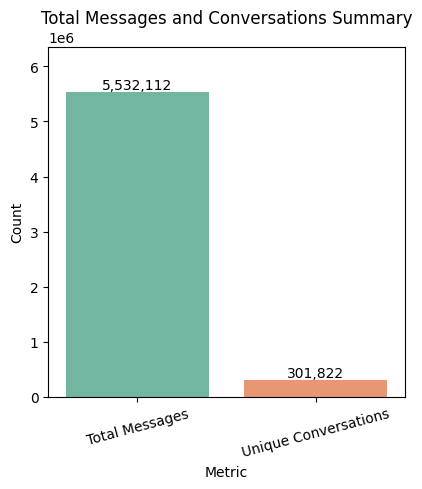

In [ ]:
plt.figure(figsize=(4.25, 5))
ax = sns.barplot(data=summary_df, x='Metric', y='Count', palette='Set2')

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

# Add spacing above tallest bar
max_height = max(summary_df['Count'])
ax.set_ylim(0, max_height * 1.15)

plt.title('Total Messages and Conversations Summary')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Total Occurences for Client and Agent

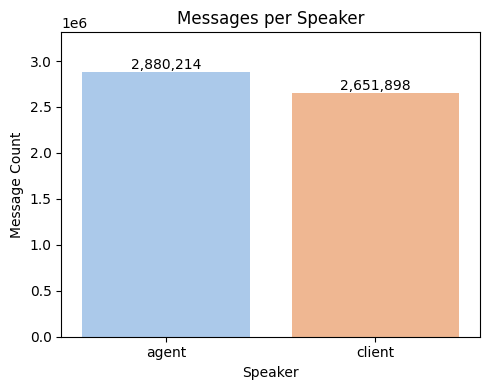

In [ ]:
plt.figure(figsize=(5, 4))
ax = sns.barplot(x=speaker_counts.index, y=speaker_counts.values, palette='pastel')

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

# Add spacing above tallest bar
ax.set_ylim(0, speaker_counts.max() * 1.15)

plt.title('Messages per Speaker')
plt.xlabel('Speaker')
plt.ylabel('Message Count')
plt.tight_layout()
plt.show()

#### Distribution of Client-Agent Turns per conversation

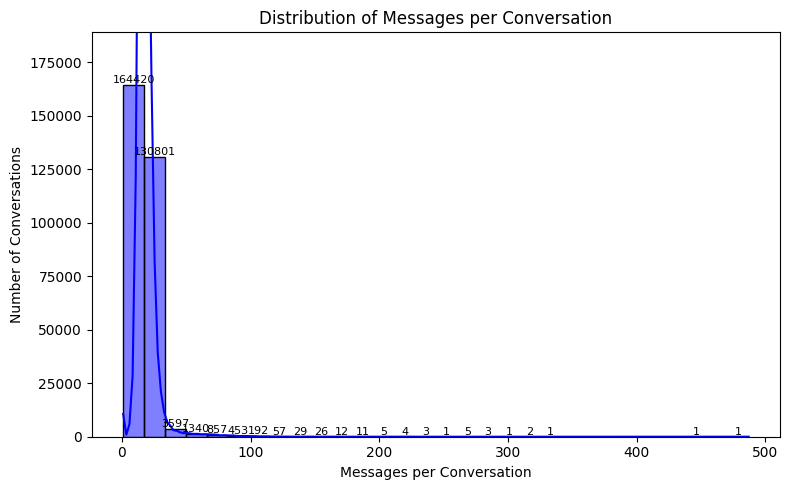

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.histplot(messages_per_conv, bins=30, kde=True, color='blue')

# Add value labels
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (bar.get_x() + bar.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8)

# Add spacing above tallest bin
heights = [bar.get_height() for bar in ax.patches]
if heights:
    ax.set_ylim(0, max(heights) * 1.15)

plt.title('Distribution of Messages per Conversation')
plt.xlabel('Messages per Conversation')
plt.ylabel('Number of Conversations')
plt.tight_layout()
plt.show()

# Filter out conversations that has more than 5 and less than 100 messages

In [ ]:
# Count messages per conversation
messages_per_conv = df['conversation_id'].value_counts()

# Get only conversation IDs with 100 or fewer messages
valid_conversations = messages_per_conv[(messages_per_conv > 5) & (messages_per_conv < 60)].index

# Filter the DataFrame
filtered_df = df[df['conversation_id'].isin(valid_conversations)]

### Statistics of Filtered Datasets

In [ ]:
print(f"Total records: {len(df):,}")

total_conversations = filtered_df['conversation_id'].nunique()
print(f"Total unique conversations: {total_conversations:,}")


messages_per_conv = filtered_df.groupby('conversation_id').size()
print(f"Average messages per conversation: {messages_per_conv.mean():.2f}")
print(f"Min messages per conversation: {messages_per_conv.min()}")
print(f"Max messages per conversation: {messages_per_conv.max()}")


speaker_counts = filtered_df['speaker'].value_counts()
print(f"Total unique speakers: {df['speaker'].nunique()}")
print(f"Agent messages: {speaker_counts.get('agent', 0):,}")
print(f"Client messages: {speaker_counts.get('client', 0):,}")

Total records: 5,532,112
Total unique conversations: 298,314
Average messages per conversation: 17.94
Min messages per conversation: 6
Max messages per conversation: 59
Total unique speakers: 2
Agent messages: 2,783,520
Client messages: 2,569,660


#### Distribution of Messages per conversation after filtered

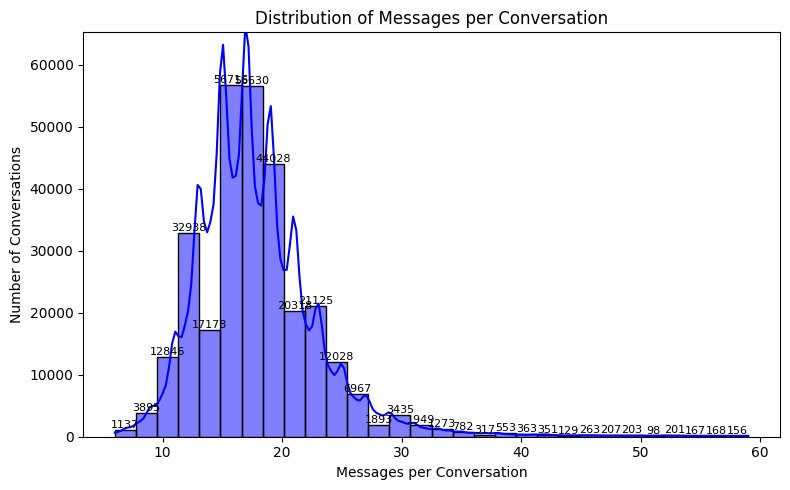

In [ ]:
plt.figure(figsize=(8, 5))
ax = sns.histplot(messages_per_conv, bins=30, kde=True, color='blue')

# Add value labels
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (bar.get_x() + bar.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8)

# Add spacing above tallest bin
heights = [bar.get_height() for bar in ax.patches]
if heights:
    ax.set_ylim(0, max(heights) * 1.15)

plt.title('Distribution of Messages per Conversation')
plt.xlabel('Messages per Conversation')
plt.ylabel('Number of Conversations')
plt.tight_layout()
plt.show()

#### Total Messages and Number of Unique conversations

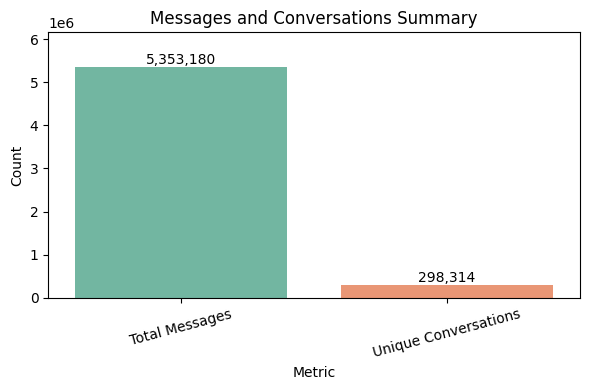

In [ ]:
summary_df = pd.DataFrame({
    'Metric': ['Total Turns', 'Unique Conversations'],
    'Count': [len(filtered_df), filtered_df['conversation_id'].nunique()]
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=summary_df, x='Metric', y='Count', palette='Set2')

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

# Add spacing above tallest bar
max_height = max(summary_df['Count'])
ax.set_ylim(0, max_height * 1.15)

plt.title('Turns and Conversations Summary')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Total Occurences for Client and Agent

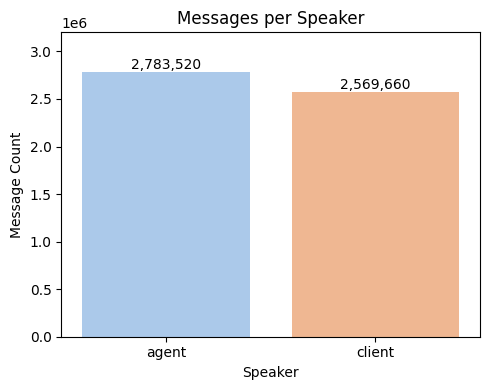

In [ ]:
plt.figure(figsize=(5, 4))
ax = sns.barplot(x=speaker_counts.index, y=speaker_counts.values, palette='pastel')

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

# Add spacing above tallest bar
ax.set_ylim(0, speaker_counts.max() * 1.15)

plt.title('Messages per Speaker')
plt.xlabel('Speaker')
plt.ylabel('Message Count')
plt.tight_layout()
plt.show()

# Final Dataset Creation

### Select 200k unique conversations from 298,314 total conversations

In [ ]:
# get first 200k unique conversation IDs
unique_conv_ids = filtered_df['conversation_id'].unique()[:200000]
print(f"Selected conversation IDs: {len(unique_conv_ids):,}")

# filter dataset to include only these conversations
filtered_df = filtered_df[filtered_df['conversation_id'].isin(unique_conv_ids)]

print(f"Filtered dataset size: {len(filtered_df):,} records")
print(f"Average messages per conversation: {len(filtered_df)/len(unique_conv_ids):.2f}")

# save the filtered dataset
output_path = '/content/drive/MyDrive/fyp-2025/Datasets/talkmap_banking_200k_conversations.csv'
filtered_df.to_csv(output_path, index=False)

Selected conversation IDs: 200,000
Filtered dataset size: 3,564,906 records
Average messages per conversation: 17.82


In [ ]:
del df, filtered_df
gc.collect() # apply Garbage collector

5744

### Load saved 200k conversations

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/fyp-2025/Datasets/talkmap_banking_200k_conversations.csv')

In [ ]:
df.head()

,conversation_id,speaker,date_time,text
0,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:33+00:00,"Good morning, thank you for calling Union Financial. My name is Monroe, how can I assist you today?"
1,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:33:41.307692+00:00,"Hi Monroe, my name is Della. I need help managing my bills. Can you help me set up automatic payments?"
2,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:50.538461+00:00,"Of course, Della. I'd be happy to help you with that. Before we get started, may you please verify your identity for me?"
3,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:34:01.153846+00:00,Sure thing. My account number is 1234567890.
4,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:04.384615+00:00,"Thank, thank you for providing that information. Now, let's discuss your payee management needs. Are there any specific bills you'd like to set up for automatic payment?"


In [ ]:
len(df)

3564906

### Statistics of the Selected 200k conversations

In [ ]:
print(f"Total records: {len(df):,}")

total_conversations = df['conversation_id'].nunique()
print(f"Total unique conversations: {total_conversations:,}")


messages_per_conv = df.groupby('conversation_id').size()
print(f"Average messages per conversation: {messages_per_conv.mean():.2f}")
print(f"Min messages per conversation: {messages_per_conv.min()}")
print(f"Max messages per conversation: {messages_per_conv.max()}")


speaker_counts = df['speaker'].value_counts()
print(f"Total unique speakers: {df['speaker'].nunique()}")
print(f"Agent messages: {speaker_counts.get('agent', 0):,}")
print(f"Client messages: {speaker_counts.get('client', 0):,}")

Total records: 3,564,906
Total unique conversations: 200,000
Average messages per conversation: 17.82
Min messages per conversation: 6
Max messages per conversation: 59
Total unique speakers: 2
Agent messages: 1,853,622
Client messages: 1,711,284


#### Total Messages and number of Unique conversations

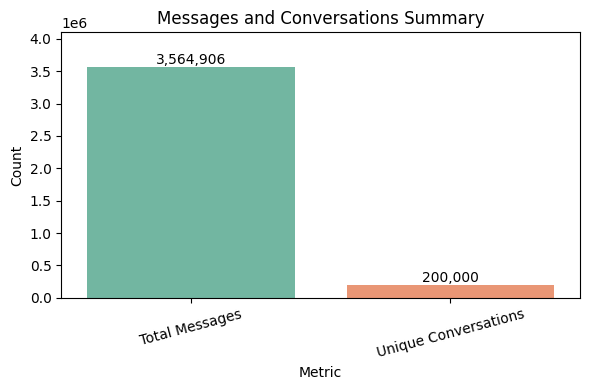

In [ ]:
summary_df = pd.DataFrame({
    'Metric': ['Total Messages', 'Unique Conversations'],
    'Count': [len(df), df['conversation_id'].nunique()]
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=summary_df, x='Metric', y='Count', palette='Set2')

# Add labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

# Add spacing above tallest bar
max_height = max(summary_df['Count'])
ax.set_ylim(0, max_height * 1.15)

plt.title('Messages and Conversations Summary')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Distribution of Messages per conversation after filtered

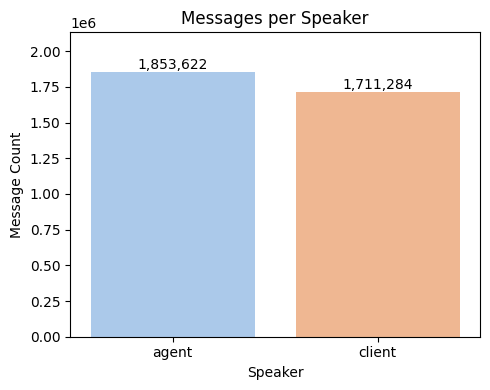

In [ ]:
plt.figure(figsize=(5, 4))
ax = sns.barplot(x=speaker_counts.index, y=speaker_counts.values, palette='pastel')

# add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

# add spacing above tallest bar
ax.set_ylim(0, speaker_counts.max() * 1.15)

plt.title('Messages per Speaker')
plt.xlabel('Speaker')
plt.ylabel('Message Count')
plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3564906 entries, 0 to 3564905
Data columns (total 4 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   conversation_id  object
 1   speaker          object
 2   date_time        object
 3   text             object
dtypes: object(4)
memory usage: 108.8+ MB


In [ ]:
df.head()

,conversation_id,speaker,date_time,text
0,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:33+00:00,"Good morning, thank you for calling Union Financial. My name is Monroe, how can I assist you today?"
1,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:33:41.307692+00:00,"Hi Monroe, my name is Della. I need help managing my bills. Can you help me set up automatic payments?"
2,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:50.538461+00:00,"Of course, Della. I'd be happy to help you with that. Before we get started, may you please verify your identity for me?"
3,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:34:01.153846+00:00,Sure thing. My account number is 1234567890.
4,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:04.384615+00:00,"Thank, thank you for providing that information. Now, let's discuss your payee management needs. Are there any specific bills you'd like to set up for automatic payment?"


### Basic Noise removal of the conversations through Regex

In [ ]:
import re

# function to clean cues from text
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\s*\([^)]+\)", "", text)        # replace (sighs), (pause)
    text = re.sub(r"\s*\*[^*]+\*\s*", "", text)        # matches expressions like *pause*, *sighs*
    text = re.sub(r'"', "", text)                   # remove quotation marks
    text = re.sub(r"\s+", " ", text)                     # normalize whitespace
    text = re.sub(r"\(", "", text)
    text = re.sub(r"\)", "", text)

    return text.strip()

In [ ]:
len(df)

3564906

In [ ]:
df["text"] = df["text"].apply(clean_text)

In [ ]:
df.head()

,conversation_id,speaker,date_time,text
0,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:33+00:00,"Good morning, thank you for calling Union Financial. My name is Monroe, how can I assist you today?"
1,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:33:41.307692+00:00,"Hi Monroe, my name is Della. I need help managing my bills. Can you help me set up automatic payments?"
2,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:33:50.538461+00:00,"Of course, Della. I'd be happy to help you with that. Before we get started, may you please verify your identity for me?"
3,2b6544c382e6423b96785c1a135d8e95,client,2023-09-06T14:34:01.153846+00:00,Sure thing. My account number is 1234567890.
4,2b6544c382e6423b96785c1a135d8e95,agent,2023-09-06T14:34:04.384615+00:00,"Thank, thank you for providing that information. Now, let's discuss your payee management needs. Are there any specific bills you'd like to set up for automatic payment?"


## Map the full conversations with respective conversation Ids

In [ ]:
import pandas as pd
from datasets import Dataset
from huggingface_hub import login

# ensure text is string
df['text'] = df['text'].astype(str)

def build_ordered_convo(group):
    convo = []
    for row in group.itertuples(index=False):
        convo.append({"speaker": row.speaker, "text": row.text})
    return convo

final_df = df.groupby('conversation_id', sort=False).apply(build_ordered_convo).reset_index(name='conversation')

In [ ]:
final_df.head(2)

,conversation_id,conversation
0,2b6544c382e6423b96785c1a135d8e95,"[{'speaker': 'agent', 'text': 'Good morning, thank you for calling Union Financial. My name is Monroe, how can I assist you today?'}, {'speaker': 'client', 'text': 'Hi Monroe, my name is Della. I need help managing my bills. Can you help me set up automatic payments?'}, {'speaker': 'agent', 'text': 'Of course, Della. I'd be happy to help you with that. Before we get started, may you please verify your identity for me?'}, {'speaker': 'client', 'text': 'Sure thing. My account number is 1234567890.'}, {'speaker': 'agent', 'text': 'Thank, thank you for providing that information. Now, let's discuss your payee management needs. Are there any specific bills you'd like to set up for automatic payment?'}, {'speaker': 'client', 'text': 'Well, I'd like to pay my electricity and gas bills automatically. But I'm not sure how to do it.'}, {'speaker': 'agent', 'text': 'No problem, Della. I can guide you through the process. First, let'll need to add your payees to our system. May I have the names of your electricity and gas providers, please?'}, {'speaker': 'client', 'text': 'Sure, my electricity provider is GreenYZ Electric, and my gas provider is ABC Gas Company.'}, {'speaker': 'agent', 'text': 'Greatcellent. Now, I'll need to confirm some information with you. Can you please provide me with the account four digits of your social security number?'}, {'speaker': 'client', 'text': 'Okay, it's 1234.'}, {'speaker': 'agent', 'text': 'Perfect, Now, let'm going to set up automatic payments for your electricity and gas bills. Is there a specific date you'd like the payments to be made on?'}, {'speaker': 'client', 'text': 'How about the 15th of every month?'}, {'speaker': 'agent', 'text': 'That works great. I've set the payments to be made on the 15th of each month. Would you like me to set up recurring payments for any other bills?'}, {'speaker': 'client', 'text': 'No, that's be all for now. Thank you so much for your help, Monroe!'}, {'speaker': 'agent', 'text': 'You're welcome, Della. It was my pleasure to assist you. If you have any further questions or concerns, don't hesitate to give us a call. Have a wonderful day!'}, {'speaker': 'client', 'text': 'Thanks, Monroe. You too!'}, {'speaker': 'agent', 'text': 'Goodbye, Della.'}]"
1,41e9647097e84e829964f2dc9f8fb27e,"[{'speaker': 'agent', 'text': 'Good morning, thank you for holding Union Financial. My name is Mitzi, how can I assist you today?'}, {'speaker': 'client', 'text': 'Hi Mitzi, I'm calling to report some spam emails that I received from your bank. I tried to report them through the website, but nothing happened.'}, {'speaker': 'agent', 'text': 'Sorry to hear that, Margery. Can you tell me more about these emails? What did they say and how did they look like?'}, {'speaker': 'client', 'text': 'Well, they were very suspicious and asked me to click on links and provide personal information. They looked quite professional, with the Union Financial logo and everything. But I knew it's not legitimate because I didn't request any information from you guys.'}, {'speaker': 'agent', 'text': 'I see. We apologize for any inconvenience this has caused, Margery. Let me assure you that we take these matters very seriously and will do our best to address the issue. Can you please forward those emails to our dedicated email address for reporting spam? We'll investigate and take appropriate action.'}, {'speaker': 'client', 'text': 'Sure, I alreadyll do that right away. But I wanted to ask, why hasn't you guys do anything about it when I reported it through the website?'}, {'speaker': 'agent', 'text': 'I apologize for the confusion, Margery. It's possible that our system didn't flag it as spam or that our team missed it. We have a large of reports coming in every day, and sometimes things slip through the cracks. But I want to assure you that we're taking steps to improve our reporting and response process.'}, {'speaker': 'client', 'text': 'O

In [ ]:
len(final_df)

200000

## De-Duplication of the Conversations (Check for duplications)

In [ ]:
import pandas as pd
import json

def normalize_conversation(conv):
    # convert list of dicts to a single JSON string
    return json.dumps(conv, sort_keys=True)

final_df['conversation_text'] = final_df['conversation'].apply(normalize_conversation)

In [ ]:
final_df['conversation_text'].head(2)

,conversation_text
0,"[{""speaker"": ""agent"", ""text"": ""Good morning, thank you for calling Union Financial. My name is Monroe, how can I assist you today?""}, {""speaker"": ""client"", ""text"": ""Hi Monroe, my name is Della. I need help managing my bills. Can you help me set up automatic payments?""}, {""speaker"": ""agent"", ""text"": ""Of course, Della. I'd be happy to help you with that. Before we get started, may you please verify your identity for me?""}, {""speaker"": ""client"", ""text"": ""Sure thing. My account number is 1234567890.""}, {""speaker"": ""agent"", ""text"": ""Thank, thank you for providing that information. Now, let's discuss your payee management needs. Are there any specific bills you'd like to set up for automatic payment?""}, {""speaker"": ""client"", ""text"": ""Well, I'd like to pay my electricity and gas bills automatically. But I'm not sure how to do it.""}, {""speaker"": ""agent"", ""text"": ""No problem, Della. I can guide you through the process. First, let'll need to add your payees to our system. May I have the names of your electricity and gas providers, please?""}, {""speaker"": ""client"", ""text"": ""Sure, my electricity provider is GreenYZ Electric, and my gas provider is ABC Gas Company.""}, {""speaker"": ""agent"", ""text"": ""Greatcellent. Now, I'll need to confirm some information with you. Can you please provide me with the account four digits of your social security number?""}, {""speaker"": ""client"", ""text"": ""Okay, it's 1234.""}, {""speaker"": ""agent"", ""text"": ""Perfect, Now, let'm going to set up automatic payments for your electricity and gas bills. Is there a specific date you'd like the payments to be made on?""}, {""speaker"": ""client"", ""text"": ""How about the 15th of every month?""}, {""speaker"": ""agent"", ""text"": ""That works great. I've set the payments to be made on the 15th of each month. Would you like me to set up recurring payments for any other bills?""}, {""speaker"": ""client"", ""text"": ""No, that's be all for now. Thank you so much for your help, Monroe!""}, {""speaker"": ""agent"", ""text"": ""You're welcome, Della. It was my pleasure to assist you. If you have any further questions or concerns, don't hesitate to give us a call. Have a wonderful day!""}, {""speaker"": ""client"", ""text"": ""Thanks, Monroe. You too!""}, {""speaker"": ""agent"", ""text"": ""Goodbye, Della.""}]"
1,"[{""speaker"": ""agent"", ""text"": ""Good morning, thank you for holding Union Financial. My name is Mitzi, how can I assist you today?""}, {""speaker"": ""client"", ""text"": ""Hi Mitzi, I'm calling to report some spam emails that I received from your bank. I tried to report them through the website, but nothing happened.""}, {""speaker"": ""agent"", ""text"": ""Sorry to hear that, Margery. Can you tell me more about these emails? What did they say and how did they look like?""}, {""speaker"": ""client"", ""text"": ""Well, they were very suspicious and asked me to click on links and provide personal information. They looked quite professional, with the Union Financial logo and everything. But I knew it's not legitimate because I didn't request any information from you guys.""}, {""speaker"": ""agent"", ""text"": ""I see. We apologize for any inconvenience this has caused, Margery. Let me assure you that we take these matters very seriously and will do our best to address the issue. Can you please forward those emails to our dedicated email address for reporting spam? We'll investigate and take appropriate action.""}, {""speaker"": ""client"", ""text"": ""Sure, I alreadyll do that right away. But I wanted to ask, why hasn't you guys do anything about it when I reported it through the website?""}, {""speaker"": ""agent"", ""text"": ""I apologize for the confusion, Margery. It's possible that our system didn't flag it as spam or that our team missed it. We have a large of reports coming in every day, and sometimes things slip through the cracks. But I want to ass

In [ ]:
dedup_df = final_df.drop_duplicates(subset=['conversation_text']).reset_index(drop=True)

In [ ]:
len(dedup_df)

200000

In [ ]:
final_df = dedup_df.drop(columns=['conversation_text'])

## Add Synthetic Companies

In [ ]:
# define synthetic company names pool
synthetic_companies = [
    # Banks
    "NovaBank", "FinEdge", "TrustLine", "SecureBank", "Zenith Financial", "SkyTrust",
    "EcoCapital", "PrimeFunds", "CrestBank", "AlphaBank", "VanguardBank", "PinnacleBank",
    "MetroBank", "SummitBank", "HorizonBank", "NexusBank", "EliteBank", "ProspectBank",
    "UnityBank", "CoreBank", "VitalBank", "CatalystBank", "EvolveBank", "ThriveBank",
    "FirstTrust Bank", "CentralBank", "EagleBank", "RiverBank", "MountainBank", "ValleyBank",
    "CityBank", "StateBank", "NationalBank", "RegionalBank", "CommunityBank", "HeritageBank",
    "LibertyBank", "ProgressBank", "InnovationBank", "TrustPoint Bank", "CapitalOne Bank",
    "PremierBank", "OptimalBank", "DynamicBank", "StrategicBank", "FlexiBank", "ModernBank",

    # Financial Companies
    "Apex Financial", "Sterling Financial", "Meridian Financial", "Phoenix Financial",
    "Prism Financial", "Cornerstone Financial", "Velocity Financial", "Lumina Financial",
    "Titan Financial", "Clarity Financial", "Momentum Financial", "Nexus Financial",
    "Ascent Financial", "Beacon Financial", "Global Financial Partners", "Premier Financial Group",
    "Strategic Financial Solutions", "Dynamic Financial Corp", "Elite Financial Services",
    "Optimal Financial Partners", "Peak Financial Solutions", "Unity Financial Group",
    "Heritage Financial Services", "Liberty Financial Corp", "Progress Financial Partners",
    "Innovation Financial Group", "TrustPoint Financial", "Capital Financial Services",
    "Modern Financial Solutions", "Future Financial Partners", "Pinnacle Financial Group",
    "Summit Financial Services", "Horizon Financial Corp", "Crest Financial Partners",
    "Eagle Financial Group", "River Financial Services", "Mountain Financial Corp",
    "Valley Financial Partners", "City Financial Group", "State Financial Services",
    "National Financial Corp", "Regional Financial Partners", "Community Financial Group"
]

## Create Client-Agent answer pairs with history (adding synthetic names)

In [ ]:
# Create a question–answer dataset from multi-turn conversations.

#     The below function processes raw conversation transcripts into a structured
#     dataset suitable for training customer service dialogue models. It does the following:
#       1. Iterates over conversations and truncates to a maximum number of turns.
#       2. Identifies client-agent turn pairs to extract as question–answer samples.
#       3. Randomly selects one such pair from early, middle, or late in the conversation
#          (with higher probability for middle turns).
#       4. Replaces any mention of "Union Financial" with a randomly chosen synthetic
#          company name to anonymize the data. (since talkmap dataset consist with synthetic company names)
#       5. Builds an instruction prompt, the client’s question, the agent’s answer,
#          and the prior dialogue history leading up to that question.
#       6. Returns a DataFrame containing these structured fields.

In [ ]:
import pandas as pd
import random
import re
import tiktoken

# Initialize GPT tokenizer (cl100k_base works for GPT-3.5/4)
enc = tiktoken.get_encoding("cl100k_base")

def create_question_answer_dataset_with_synthetic_names(
    final_df,
    max_turns=60,
    seed=42
):
    #  synthetic_companies
    global synthetic_companies
    synthetic_names = synthetic_companies

    # Set random seed for reproducibility
    random.seed(seed)
    qa_rows = []

    # Regex to remove "Union Financial" in any case/spacing
    pattern = re.compile(r"u\s*n\s*i\s*o\s*n\s*f\s*i\s*n\s*a\s*n\s*c\s*i\s*a\s*l", re.IGNORECASE)

     # Count tokens with GPT tokenizer
    def token_count(text: str) -> int:
        """Return token count using GPT tokenizer."""
        return len(enc.encode(text))

    # Iterate through each conversation
    for _, row in final_df.iterrows():
        conv_id = row['conversation_id']
        conv = row['conversation'][:max_turns] # truncate to max_turns


        # Candidate positions are client turns followed by an agent response
        candidate_indices = [
            i for i in range(len(conv) - 1)
            if conv[i]['speaker'] == 'client'
            and conv[i + 1]['speaker'] == 'agent'
        ]
        if not candidate_indices:
            continue # skip if no client→agent pair exists

        conv_len = len(conv)

        # Randomly select a section of the conversation:
        # Early (first third), middle (middle third), or late (final third)
        section = random.choices(
            ["early", "middle", "late"],
            weights=[0.2, 0.7, 0.1], # Given priority on Middle Turn Conversations
            k=1
        )[0]

        if section == "early":
            start, end = 0, conv_len * (1/3)
        elif section == "middle":
            start, end = conv_len * (1/3), conv_len * (2/3)
        else:
            start, end = conv_len * (2/3), conv_len

        target_pos = random.uniform(start, end)

        # Pick the client-agent pair closest to a random target position
        chosen_idx = min(candidate_indices, key=lambda x: abs(x - target_pos))

        # Extract client question and agent answer
        client_text = conv[chosen_idx]['text']
        agent_text = conv[chosen_idx + 1]['text']

        # Skip if either turn is very short (<6 tokens)
        if token_count(client_text) < 6 or token_count(agent_text) < 6:
            continue  # Skip if either is too short

         # Assign a synthetic company name to this conversation
        synthetic_name = random.choice(synthetic_names)

        # Replace occurrences of "Union Financial" with the synthetic name
        def clean_text(txt):
            return pattern.sub(synthetic_name, txt)

        # Build history: all turns before the chosen client question
        history = [
            {"speaker": h["speaker"], "text": clean_text(h["text"])}
            for h in conv[:chosen_idx]
        ]

         # Clean the selected client and agent texts
        client_question = clean_text(client_text)
        agent_answer = clean_text(agent_text)

        # Initial Instruction column with company name
        instruction = (
          f"You are a professional customer service agent working at **{synthetic_name}**, "
          "a financial services institution. Carefully review the full conversation history "
          "between the client and agent, along with any additional context provided. "
          "Use all available information to generate a clear, helpful, and professional agent response "
          f"representing **{synthetic_name}**."
        )

         # Collect the final row
        qa_rows.append({
            "conversation_id": conv_id,
            "instruction": instruction,
            "client_question": client_question,
            "agent_answer": agent_answer,
            "history": history
        })

    # Convert all rows into a DataFrame
    qa_df = pd.DataFrame(
        qa_rows,
        columns=["conversation_id", "instruction", "client_question", "agent_answer", "history"]
    )
    return qa_df

# Run the preprocessing to generate the dataset
qa_df = create_question_answer_dataset_with_synthetic_names(final_df)

In [ ]:
qa_df.head(2)

,conversation_id,instruction,client_question,agent_answer,history
0,2b6544c382e6423b96785c1a135d8e95,"You are a professional customer service agent working at **HeritageBank**, a financial services institution. Carefully review the full conversation history between the client and agent, along with any additional context provided. Use all available information to generate a clear, helpful, and professional agent response representing **HeritageBank**.","Well, I'd like to pay my electricity and gas bills automatically. But I'm not sure how to do it.","No problem, Della. I can guide you through the process. First, let'll need to add your payees to our system. May I have the names of your electricity and gas providers, please?","[{'speaker': 'agent', 'text': 'Good morning, thank you for calling HeritageBank. My name is Monroe, how can I assist you today?'}, {'speaker': 'client', 'text': 'Hi Monroe, my name is Della. I need help managing my bills. Can you help me set up automatic payments?'}, {'speaker': 'agent', 'text': 'Of course, Della. I'd be happy to help you with that. Before we get started, may you please verify your identity for me?'}, {'speaker': 'client', 'text': 'Sure thing. My account number is 1234567890.'}, {'speaker': 'agent', 'text': 'Thank, thank you for providing that information. Now, let's discuss your payee management needs. Are there any specific bills you'd like to set up for automatic payment?'}]"
1,41e9647097e84e829964f2dc9f8fb27e,"You are a professional customer service agent working at **SummitBank**, a financial services institution. Carefully review the full conversation history between the client and agent, along with any additional context provided. Use all available information to generate a clear, helpful, and professional agent response representing **SummitBank**.","Sure, I alreadyll do that right away. But I wanted to ask, why hasn't you guys do anything about it when I reported it through the website?","I apologize for the confusion, Margery. It's possible that our system didn't flag it as spam or that our team missed it. We have a large of reports coming in every day, and sometimes things slip through the cracks. But I want to assure you that we're taking steps to improve our reporting and response process.","[{'speaker': 'agent', 'text': 'Good morning, thank you for holding SummitBank. My name is Mitzi, how can I assist you today?'}, {'speaker': 'client', 'text': 'Hi Mitzi, I'm calling to report some spam emails that I received from your bank. I tried to report them through the website, but nothing happened.'}, {'speaker': 'agent', 'text': 'Sorry to hear that, Margery. Can you tell me more about these emails? What did they say and how did they look like?'}, {'speaker': 'client', 'text': 'Well, they were very suspicious and asked me to click on links and provide personal information. They looked quite professional, with the SummitBank logo and everything. But I knew it's not legitimate because I didn't request any information from you guys.'}, {'speaker': 'agent', 'text': 'I see. We apologize for any inconvenience this has caused, Margery. Let me assure you that we take these matters very seriously and will do our best to address the issue. Can you please forward those emails to our dedicated email address for reporting spam? We'll investigate and take appropriate action.'}]"


## Remove agent only exist conversations in the history

In [ ]:
from datasets import Dataset

# Convert a pandas DataFrame (qa_df) into a Hugging Face Dataset
qa_df = Dataset.from_pandas(qa_df)

#  Collect the set of speaker roles in the history
#  If the history contains ONLY "agent" turns (no client turns)
#   and has at least 2 turns, we discard it.
#  Otherwise,keep the row.
def keep_row(ex):
    s = {t["speaker"].lower() for t in ex["history"]}
    return not (s == {"agent"} and len(ex["history"]) >= 2)

# Apply the filter to remove unwanted rows
qa_df = qa_df.filter(keep_row)

Filter:   0%|          | 0/185309 [00:00<?, ? examples/s]

In [ ]:
len(qa_df) # Check the length of the dataset

183337

In [ ]:
qa_df = qa_df.to_pandas()

In [ ]:
from datasets import Dataset
from huggingface_hub import HfApi, HfFolder

# Convert pandas DataFrame to Hugging Face Dataset
hf_dataset = Dataset.from_pandas(qa_df)

# Define dataset name
dataset_name = "Lakshan2003/customer_service_200k_client_agent_conversations"

# Push to the Hub
hf_dataset.push_to_hub(dataset_name)

print(f"Dataset pushed to https://huggingface.co/datasets/{dataset_name}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/187 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :   2%|1         | 2.10MB /  134MB            

README.md:   0%|          | 0.00/743 [00:00<?, ?B/s]

Dataset pushed to https://huggingface.co/datasets/Lakshan2003/customer_service_200k_client_agent_conversations


## Train, Test, Validation dataset Split (After summarisation merged again)

In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# First: split out 20% test
train_val_df, test_df = train_test_split(qa_df, test_size=0.20, random_state=42)

# Then: split train vs validation (10% of total -> 10/80 = 0.125 of remaining data)
train_df, val_df = train_test_split(train_val_df, test_size=0.125, random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Convert to Hugging Face Dataset objects
dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})

Train: 128335, Val: 18334, Test: 36668


## Push the dataset to Hub

In [ ]:
dataset_dict.push_to_hub("Lakshan2003/customer_service_200k_client_agent_conversations")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/129 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :   1%|1         | 1.05MB / 99.1MB            

...

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :  87%|########7 | 24.7MB / 28.3MB            

README.md:   0%|          | 0.00/834 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Lakshan2003/customer_service_200k_client_agent_conversations/commit/3b87d75ddecedec902786e83922c30e85c834f69', commit_message='Upload dataset', commit_description='', oid='3b87d75ddecedec902786e83922c30e85c834f69', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Lakshan2003/customer_service_200k_client_agent_conversations', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Lakshan2003/customer_service_200k_client_agent_conversations'), pr_revision=None, pr_num=None)

### Text String for client agent history

In [ ]:
import pandas as pd
from datasets import load_dataset
import json


data = load_dataset("Lakshan2003/customer_service_200k_client_agent_conversations")


data

README.md:   0%|          | 0.00/834 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/171M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/24.3M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/48.7M [00:00<?, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['conversation_id', 'instruction', 'client_question', 'agent_answer', 'history', 'history_string', 'history_token_count'],
        num_rows: 128335
    })
    validation: Dataset({
        features: ['conversation_id', 'instruction', 'client_question', 'agent_answer', 'history', 'history_string', 'history_token_count'],
        num_rows: 18334
    })
    test: Dataset({
        features: ['conversation_id', 'instruction', 'client_question', 'agent_answer', 'history', 'history_string', 'history_token_count'],
        num_rows: 36668
    })
})

In [ ]:
data["train"][0]["history"]

[{'speaker': 'agent',
  'text': 'Good morning, thank you for calling Crest Financial Partners. My name is Dena, how can I assist you today?'},
 {'speaker': 'agent',
  'text': 'Of course, Shirley. Can you please verify your identity for me by providing your full name and date of birth?'},
 {'speaker': 'client',
  'text': 'Sure, my name is Shirley Johnson and my date of birth is February 12,, 1980.'},
 {'speaker': 'agent',
  'text': "Thank you, Shirley. I justm having going to check some information real quick. It looks like we have a few different accounts associated with your name and datedate. Can you please confirm which account you'd like to update the address for?"},
 {'speaker': 'client',
  'text': "Oh, I didn't realize that. Let me check... Yeahah, it lookss my checking account."},
 {'speaker': 'agent',
  'text': 'Great! I just need to ask you a few more questions to verify your identity. Can you tell me the last time you logged into your online banking?'},
 {'speaker': 'client',

### Create History Text String Formetted Column with client agent Occurunces

In [ ]:
import re
import unicodedata

# Normalize text:
#  Apply standard Unicode normalization
#  Collapse multiple spaces/tabs into one space
#  Trim leading/trailing whitespace
def _norm_text(s: str) -> str:
    if not s:
        return ""
    t = unicodedata.normalize("NFKC", s)
    t = re.sub(r"[ \t]+", " ", t).strip()
    return t


# Convert a conversation history (list of turns) into a single string.
# Only keep client/agent turns, and format as:
#   Client: ...
#   Agent: ...
def history_to_string(history) -> str:
    if not history:
        return ""
    lines = []
    for turn in history:
        role = (turn.get("speaker") or "").strip().lower()
        if role not in ("client", "agent"):
            continue  # ignore other roles
        text = _norm_text(turn.get("text") or "")
        if not text:
            continue
        # Preserve original casing for labels
        label = "Client" if role == "client" else "Agent"
        lines.append(f"{label}: {text}")
    return "\n".join(lines)


# Add a new column "history_string" to each batch,
# converting the structured "history" into plain text
def add_history_string(batch):
    hs = batch["history"]
    batch["history_string"] = [history_to_string(h) for h in hs]
    return batch


# Apply the mapping to the dataset in parallel
data = data.map(
    add_history_string,
    batched=True,
    desc="[history → history_string]",
    num_proc=4
)

[history → history_string (Client/Agent newline)] (num_proc=4):   0%|          | 0/128335 [00:00<?, ? examples…

[history → history_string (Client/Agent newline)] (num_proc=4):   0%|          | 0/18334 [00:00<?, ? examples/…

[history → history_string (Client/Agent newline)] (num_proc=4):   0%|          | 0/36668 [00:00<?, ? examples/…

In [ ]:
data["train"][0]

{'conversation_id': '8b3cfca253084f7284c3d5b618843980',
 'instruction': 'You are a professional customer service agent working at **Crest Financial Partners**, a financial services institution. Carefully review the full conversation history between the client and agent, along with any additional context provided. Use all available information to generate a clear, helpful, and professional agent response representing **Crest Financial Partners**.',
 'client_question': "Nope, that's all. Thanks so much, Dena!",
 'agent_answer': "You're welcome, Shirley. Have a great day!",
 'history': [{'speaker': 'agent',
   'text': 'Good morning, thank you for calling Crest Financial Partners. My name is Dena, how can I assist you today?'},
  {'speaker': 'agent',
   'text': 'Of course, Shirley. Can you please verify your identity for me by providing your full name and date of birth?'},
  {'speaker': 'client',
   'text': 'Sure, my name is Shirley Johnson and my date of birth is February 12,, 1980.'},
  

### Count GPT Tokenizer Count for history to get stats for summarization

In [ ]:
import tiktoken

# Get a GPT-4-compatible encoder
def get_gpt4_encoder():
    try:
        return tiktoken.encoding_for_model("gpt-4")
    except Exception:
        return tiktoken.get_encoding("cl100k_base")

enc = get_gpt4_encoder()

# Add history token count using GPT-4 encoder
def add_history_token_count(batch):
    texts = batch["history_string"]
    # Allow any special-like sequences without errors
    batch["history_token_count"] = [
        len(enc.encode(t or "", disallowed_special=()))
        for t in texts
    ]
    return batch

# Map function across dataset
data = data.map(
    add_history_token_count,
    batched=True,
    desc="[history_string -> GPT-4 token count]",
    num_proc=4
)

# Quick check
print(data)
print(data["train"][0]["history_string"])
print(data["train"][0]["history_token_count"])

DatasetDict({
    train: Dataset({
        features: ['conversation_id', 'instruction', 'client_question', 'agent_answer', 'history', 'history_string', 'history_token_count'],
        num_rows: 128335
    })
    validation: Dataset({
        features: ['conversation_id', 'instruction', 'client_question', 'agent_answer', 'history', 'history_string', 'history_token_count'],
        num_rows: 18334
    })
    test: Dataset({
        features: ['conversation_id', 'instruction', 'client_question', 'agent_answer', 'history', 'history_string', 'history_token_count'],
        num_rows: 36668
    })
})
Agent: Good morning, thank you for calling Crest Financial Partners. My name is Dena, how can I assist you today?
Agent: Of course, Shirley. Can you please verify your identity for me by providing your full name and date of birth?
Client: Sure, my name is Shirley Johnson and my date of birth is February 12,, 1980.
Agent: Thank you, Shirley. I justm having going to check some information real quic

In [ ]:
repo_id = "Lakshan2003/customer_service_200k_client_agent_conversations"
make_private = False  # Make dataset Private

# This will create the repo if it doesn't exist, or add a new commit if it does.
data.push_to_hub(
    repo_id=repo_id,
    private=make_private,
)
print(f"Pushed to https://huggingface.co/datasets/{repo_id}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/129 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :  15%|#4        | 25.1MB /  171MB            

...

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :  69%|######8   | 33.5MB / 48.7MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/datasets/Lakshan2003/customer_service_200k_client_agent_conversations


### Token count stat in the history for summarization

In [ ]:
from datasets import load_dataset

# Load dataset with token counts already included
repo_id = "Lakshan2003/customer_service_200k_client_agent_conversations"
data = load_dataset(repo_id)

# Per-split stats
total_counts = []
print("Split-wise statistics:")
for split, ds in data.items():
    counts = ds["history_token_count"]
    n = len(counts)
    total_counts.extend(counts)
    print(
        split,
        {
            "examples": n,
            "total_tokens": int(sum(counts)),
            "avg_tokens": (sum(counts) / n) if n else 0,
            "min": min(counts) if n else 0,
            "max": max(counts) if n else 0,
        }
    )

# Whole dataset stats
n_all = len(total_counts)
print("\nWhole dataset statistics:")
print(
    {
        "examples": n_all,
        "total_tokens": int(sum(total_counts)),
        "avg_tokens": (sum(total_counts) / n_all) if n_all else 0,
        "min": min(total_counts) if n_all else 0,
        "max": max(total_counts) if n_all else 0,
    }
)

README.md:   0%|          | 0.00/834 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/171M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/24.3M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/48.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/128335 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/18334 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/36668 [00:00<?, ? examples/s]

Split-wise statistics:
train {'examples': 128335, 'total_tokens': 34618842, 'avg_tokens': 269.75370709471304, 'min': 0, 'max': 2074}
validation {'examples': 18334, 'total_tokens': 4917707, 'avg_tokens': 268.2288098614596, 'min': 0, 'max': 1879}
test {'examples': 36668, 'total_tokens': 9877083, 'avg_tokens': 269.3651958110614, 'min': 0, 'max': 2277}

Whole dataset statistics:
{'examples': 183337, 'total_tokens': 49413632, 'avg_tokens': 269.52351134795487, 'min': 0, 'max': 2277}


## Refine Agent Answer

In [ ]:
# Silence HuggingFace progress bars and disable dataset caching to avoid hashing warnings.
disable_progress_bar()
disable_caching()

### Settings for text generation

In [ ]:
# Dataset with Instruction,history summary, client_question, agent_answer
dataset_name   = "Lakshan2003/customer_service_200k_with_summaries"
split          = "train" # Split used for the refinement

# Unique ID for each row used for resume logic
id_col         = "conversation_id"

# Batch/parallelism controls.
BATCH_SIZE     = 100        # Batch Size
MAX_ROWS       = None       # None if entire split, otherwise whole dataset
NUM_PROC       = 2          # To keep Api calls within the rate limits

# drive file and temp file to write refined agent answers
out_csv        = f"/content/drive/MyDrive/fyp-2025/Datasets/RefinedAnswers/{split}/refined_agent_answers.csv"
tmp_csv        = out_csv + ".tmp"

# OpenAI model settings
MODEL              = "gpt-4.1-2025-04-14" # Selected Model for Refinement
TEMPERATURE        = 0.4           # Temperature value used for the refinement
MAX_OUTPUT_TOKENS  = 200           # Max output tokens set

# Final CSV schema
COLUMNS_TO_SAVE = [
    id_col,
    "instruction",          # Instruction Column
    "summary",              # previous client–agent engagement summary
    "client_question",      # Client Question
    "agent_answer",         # original Answer
    "refined_agent_answer", # Model's Refined Answer
    "orig_idx"              # Index of the records
]

### Helper Functions

In [ ]:
def fmt_eta(seconds: float) -> str:
    # Format seconds into HH:MM:SS string (for progress/ETA display)
    seconds = max(0, int(seconds))
    h = seconds // 3600             # hours
    m = (seconds % 3600) // 60      # minutes
    s = seconds % 60                # seconds
    return f"{h:02d}:{m:02d}:{s:02d}"

def _safe_str(v):
    # Convert values to safe strings for prompts/CSV (handle None/NaN)
    if v is None: return ""
    if isinstance(v, float) and math.isnan(v): return ""
    return str(v)

def normalize_for_csv(ds_flat):
    # Keep only required columns (from COLUMNS_TO_SAVE)
    keep = [c for c in COLUMNS_TO_SAVE if c in ds_flat.column_names]
    ds_sel = ds_flat.select_columns(keep)

    def to_str(batch):
        out = {}
        for c in keep:
            if c == "orig_idx":
                # Keep orig_idx as integer for ordering
                out[c] = batch[c]
            else:
                # Convert all other values to safe strings
                out[c] = [_safe_str(v) for v in batch[c]]
        return out

    # Apply conversion across dataset
    return ds_sel.map(to_str, batched=True, load_from_cache_file=False)

def atomic_write_csv(ds_to_write, dst_path, tmp_path):
    # Write to a temporary file first, then move it to final path
    # This avoids corrupt/partial CSVs if something fails mid-write
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    ds_to_write.to_csv(tmp_path,  encoding="utf-8-sig")
    os.replace(tmp_path, dst_path)


def ascii_punct(s: str) -> str:
   # Replace smart quotes/dashes with ASCII equivalents before saving to csv
    return (s.replace("’", "'")
             .replace("‘", "'")
             .replace("“", '"')
             .replace("”", '"')
             .replace("—", "-")
             .replace("–", "-"))

### Lod and Window the dataset

In [ ]:
# Add "orig_idx" column to each row.
ds_full = load_dataset(dataset_name)[split].map(
    lambda ex, i: {"orig_idx": i},     # attach row index as new column
    with_indices=True,                 # provide index `i` to the lambda
    load_from_cache_file=False
)

# If Max_row limit mentioned, limit the dataset to a smaller number of rows for testing
ds_target = ds_full.select(range(min(MAX_ROWS, len(ds_full)))) if isinstance(MAX_ROWS, int) else ds_full

README.md:   0%|          | 0.00/602 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/149M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/148M [00:00<?, ?B/s]

### RESUME LOGIC

In [ ]:
# If an output CSV already exists, skip rows that were already processed.
if os.path.exists(out_csv):
    existing = load_dataset("csv", data_files=out_csv)["train"]
    done_ids = set(map(str, existing[id_col]))             # IDs already completed
    # Keep only rows whose IDs are not in the completed set
    ds_remaining = ds_target.filter(lambda x: str(x[id_col]) not in done_ids)
else:
    # If no output file exists, process all rows
    ds_remaining = ds_target

# Show progress: total rows in target window and how many remain
total_target = len(ds_target)
total_to_do  = len(ds_remaining)
print(f"[info] Target window: {total_target} rows (MAX_ROWS={MAX_ROWS if MAX_ROWS else 'ALL'})")
print(f"[info] Remaining: {total_to_do} rows to process")

# Stop if there is nothing left to proces
if total_to_do == 0:
    raise SystemExit("Nothing left to process in the selected window. All done.")

[info] Target window: 183337 rows (MAX_ROWS=ALL)
[info] Remaining: 18437 rows to process


### Refine Prompt

In [ ]:
# Refined Prompt
REFINE_PROMPT = """
You are a call-center customer service agent. Rewrite the agent’s answer so it sounds like a real phone response clear natural and helpful.

Requirements:
- Aim for 2–3 short spoken-style sentences. Use 4 only if a clear explanation is required.
- Start by acknowledging the customer’s situation, then give the solution or next step right away.
- Keep facts consistent with the context; do not invent details.
- If key information is missing, ask just one short clarifying question. Explain why you need it in plain terms.
- Avoid internal jargon, tool references, URLs, or repeating the full client question.
- Use greetings or sign-offs only when appropriate:
  * If the call is ending, close with a short thank-you using the company name.
  * If the issue isn’t resolved but can be completed now (like confirming details or filling a form), offer to stay on the line until it’s done.
- Keep the tone professional but natural, like a friendly call center agent. Avoid robotic or overly scripted phrasing.
- Do not use emojis or symbols.
- Keep responses concise unless more detail is necessary for clarity.
- Use the client’s name when possible.
- Only generate the response to clients question, do not generate the agent talking conversations with intermidiate branches.
- Preserve the original meaning and supportive intent of the agent’s answer.
- If the client asks for calculations, give the result plainly (no formulas).

Context:
Instruction: {instruction}
Previous client–agent summary: {summary}
Client’s current question: {client_question}
Original agent answer: {agent_answer}

Rewrite only the final agent answer:
"""

### BATCH MAP FUNCTION

In [ ]:
def hf_openai_refine(batch, model: str, temperature: float, max_output_tokens: int):
    client = OpenAI() # Open AI Client
    refined = []    # List to store batch refined results

    # Extract the relevant fields from the batch
    instrs   = batch.get("instruction", [])
    sums     = batch.get("summary", [])
    questions= batch.get("client_question", [])
    answers  = batch.get("agent_answer", [])

    # Process each record in parallel lists
    for ins, s, q, a in zip(instrs, sums, questions, answers):
        # Ensure all values are safe strings (handle None)
        ins = _safe_str(ins)
        s   = _safe_str(s)
        q   = _safe_str(q)
        a   = _safe_str(a)

        # If both question and answer are empty, skip refinement
        if q == "" and a == "":
            refined.append("")
            continue

        # Build the prompt for refinement
        prompt = REFINE_PROMPT.format(
            instruction=ins,
            summary=s,
            client_question=q,
            agent_answer=a
        )

        try:
            # Call OpenAI model to refine the agent’s answer
            resp = client.responses.create(
                model=model,
                input=prompt,
                temperature=temperature,
                max_output_tokens=max_output_tokens,
            )

            # Clean response text and normalize punctuation
            text = resp.output_text.strip()
            text = ascii_punct(text)
            refined.append(text)
        except Exception as e:
            # On error, print message and fall back to original answer
            print(f"OpenAI error: {e}")
            refined.append(ascii_punct(a))

    # Return new column containing the refined answers
    return {"refined_agent_answer": refined}

In [ ]:
total_to_do_int = int(len(ds_remaining))
pbar = tqdm(total=total_to_do_int, desc="Refining", unit="rows")
start_time = time.time()

# Process the dataset in batches
for start in range(0, total_to_do_int, BATCH_SIZE):
    end = min(start + BATCH_SIZE, total_to_do_int)
    batch = ds_remaining.select(range(start, end))

    # Apply the refinement function on this batch using Hugging Face map
    batch_done = batch.map(
        hf_openai_refine,
        batched=True,
        batch_size=BATCH_SIZE,
        num_proc=NUM_PROC,  # parallel workers inside map
        fn_kwargs={
            "model": MODEL,
            "temperature": TEMPERATURE,
            "max_output_tokens": MAX_OUTPUT_TOKENS,
        },
        load_from_cache_file=False,
    )

    # Keep only the required columns and restore original row order
    batch_out = normalize_for_csv(batch_done).sort("orig_idx")

    # Merge the new batch into the on-disk CSV
    if os.path.exists(out_csv):
        # Load existing CSV and append the new batch
        existing = load_dataset("csv", data_files=out_csv)["train"]
        merged = concatenate_datasets([existing, batch_out]).sort("orig_idx")

        # Deduplicate by conversation_id, keeping the first occurrence
        seen = set()
        def keep_first(example):
            cid = example[id_col]
            if cid in seen:
                return False
            seen.add(cid)
            return True

        merged = merged.filter(keep_first, load_from_cache_file=False)
        atomic_write_csv(merged, out_csv, tmp_csv)
    else:
        # If no output exists yet, write this batch as the initial file
        atomic_write_csv(batch_out, out_csv, tmp_csv)

    # Progress and ETA calculation
    processed = end
    elapsed = time.time() - start_time
    rate = processed / elapsed if elapsed > 0 else 0.0
    remaining = total_to_do_int - processed
    eta = fmt_eta(remaining / rate) if rate > 0 else "unknown"

    # Update the progress bar and log detailed progress
    pbar.update(end - start)
    pbar.set_postfix({"elapsed": fmt_eta(elapsed), "eta": eta})
    print(f"Saved rows {start}–{end} | Processed={processed}/{total_to_do_int} | Elapsed={fmt_eta(elapsed)} | ETA={eta}")

pbar.close()

Refining:   1%|          | 100/18437 [01:25<4:22:09,  1.17rows/s, elapsed=00:01:25, eta=04:22:09]

Saved rows 0–100 | Processed=100/18437 | Elapsed=00:01:25 | ETA=04:22:09


Refining:   1%|          | 200/18437 [03:20<5:12:00,  1.03s/rows, elapsed=00:03:20, eta=05:04:18]

Saved rows 100–200 | Processed=200/18437 | Elapsed=00:03:20 | ETA=05:04:18


Refining:   2%|▏         | 300/18437 [04:54<4:58:33,  1.01rows/s, elapsed=00:04:54, eta=04:56:37]

...

Saved rows 18200–18300 | Processed=18300/18437 | Elapsed=04:59:13 | ETA=00:02:14


Refining: 100%|█████████▉| 18400/18437 [5:01:03<00:39,  1.06s/rows, elapsed=05:01:03, eta=00:00:36]

Saved rows 18300–18400 | Processed=18400/18437 | Elapsed=05:01:03 | ETA=00:00:36


Refining: 100%|██████████| 18437/18437 [5:01:59<00:00,  1.02rows/s, elapsed=05:01:59, eta=00:00:00]

Saved rows 18400–18437 | Processed=18437/18437 | Elapsed=05:01:59 | ETA=00:00:00


### Create Hugginface dataframe from refined answers

In [ ]:
from datasets import load_dataset, Features, Value
from huggingface_hub import login, HfApi

# Path to the CSV file containing the refined answers
out_csv = "/content/drive/MyDrive/fyp-2025/Datasets/RefinedAnswers/train/refined_agent_answers.csv"

# Load the CSV into a Hugging Face Dataset
ds = load_dataset("csv", data_files=out_csv)["train"]

# Explicitly define the schema with all 7 columns
features = Features({
    "conversation_id": Value("string"),
    "instruction": Value("string"),
    "summary": Value("string"),
    "client_question": Value("string"),
    "agent_answer": Value("string"),
    "refined_agent_answer": Value("string"),
    "orig_idx": Value("int64")   # since it's an index, make it integer
})


# Cast the dataset to use the defined schema
ds = ds.cast(features)

# Sort the dataset back into original orde
ds = ds.sort("orig_idx")

Generating train split: 0 examples [00:00, ? examples/s]

Casting the dataset:   0%|          | 0/183337 [00:00<?, ? examples/s]

In [ ]:
# Remove the helper column "orig_idx" since it was only used for ordering
ds = ds.remove_columns("orig_idx")

# Redefine the schema with only the final 6 columns (all strings)
features = Features({
    "conversation_id": Value("string"),
    "instruction": Value("string"),
    "summary": Value("string"),
    "client_question": Value("string"),
    "agent_answer": Value("string"),
    "refined_agent_answer": Value("string")
})

# Cast the dataset to the cleaned schema to enforce consistent types
ds = ds.cast(features)

Casting the dataset:   0%|          | 0/183337 [00:00<?, ? examples/s]

In [ ]:
# Push the finalized dataset to the Hugging Face Hub
user_or_org = "Lakshan2003"                   # HF username/org
repo_name   = "customer_agent_refined_answers" # dataset repo name
repo_id     = f"{user_or_org}/{repo_name}"

api = HfApi()
api.create_repo(
    repo_id,
    repo_type="dataset",
    private=True,         # keep the repo private
    exist_ok=True
    )

# Upload data + auto-create README stub
ds.push_to_hub(repo_id, private=True)
print(f"Uploaded to https://huggingface.co/datasets/{repo_id}")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/184 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :  10%|9         | 10.5MB /  109MB            

README.md:   0%|          | 0.00/503 [00:00<?, ?B/s]

✅ Uploaded to https://huggingface.co/datasets/Lakshan2003/customer_agent_refined_answers


### Finalizing and merging columns

In [ ]:
# Load datasets from the Hub
ds_main = load_dataset("Lakshan2003/customer_agent_refined_answers", split="train")
ds_hist = load_dataset("Lakshan2003/customer_service_200k_with_summaries", split="train")

# Convert to pandas for a clean merge
df_main = ds_main.to_pandas()
df_hist = ds_hist.to_pandas()

# Rename 'summary' to 'history_summary'
if "summary" in df_main.columns:
    df_main = df_main.rename(columns={"summary": "history_summary"})

# Pick the correct history column from the other dataset and normalize its name
hist_col = "history_string"
df_hist_sub = df_hist[["conversation_id", hist_col]]

# Use customer_service_200k_with_summaries as base
merged = df_hist_sub.merge(df_main, on="conversation_id", how="left")

# Reorder columns
desired_order = [
    "conversation_id",
    "instruction",
    "history_string",
    "history_summary",
    "client_question",
    "agent_answer",
    "refined_agent_answer",
]

merged = merged.reindex(columns=desired_order)

# Convert back to a Hugging Face Dataset
final_ds = Dataset.from_pandas(merged, preserve_index=False)

# Push to the Hub (new repo to avoid overwriting the original)
target_repo = "Lakshan2003/customer_agent_with_history"
final_ds.push_to_hub(target_repo)

print(f"pushed merged dataset to https://huggingface.co/datasets/{target_repo}")

README.md:   0%|          | 0.00/503 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/109M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/183337 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/602 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/149M [00:00<?, ?B/s]

...

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :  11%|#         | 22.9MB /  211MB            

README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

pushed merged dataset to https://huggingface.co/datasets/Lakshan2003/customer_agent_with_history


## Apply moderation filtering to refined answers

In [ ]:
import os, time
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset
from openai import OpenAI
from google.colab import userdata
from collections import deque

# Config
BATCH_SIZE = 30  # number of rows per request batch
DELAY = 2        # optional extra pause after each batch
OUTFILE = "moderation_results.csv" # CSV file to save results
MODEL = "text-moderation-latest"   # OpenAI moderation model
MAX_RPM = 400                    # maximum requests per minute

# Auth
api_key = userdata.get("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI(api_key=api_key) # Create OpenAI Client

# Load dataset
ds = load_dataset("Lakshan2003/customer_agent_with_history", split="train")
texts = ds["refined_agent_answer"]
conversation_ids = ds["conversation_id"]  # map results to this

# Resume support
start = 0

# If a results file already exists, resume from the last processed row
if os.path.exists(OUTFILE):
    done = pd.read_csv(OUTFILE)
    if "_row_idx" in done.columns and not done.empty:
        start = int(done["_row_idx"].max()) + 1
print(f"Resuming from row {start} of {len(texts)}")

# RPM limiter (≤ 400 req/min)
request_times = deque(maxlen=MAX_RPM)

def throttle():
    """Block until under the MAX_RPM budget in the last 60s window."""
    if len(request_times) == request_times.maxlen:
        oldest = request_times[0]
        elapsed = time.time() - oldest

        # If the earliest request was <60s ago, wait until 60s
        if elapsed < 60.0:
            time.sleep(60.0 - elapsed + 0.01)

    # Log the time of this request
    request_times.append(time.time())

# Main loop
for i in tqdm(range(start, len(texts), BATCH_SIZE)):
    # Row indices for this batch
    batch_idxs = list(range(i, min(i + BATCH_SIZE, len(texts))))
    # Collect batch texts and IDs
    batch_texts = [texts[j] for j in batch_idxs]
    batch_conv_ids = [conversation_ids[j] for j in batch_idxs]

    try:
        throttle()   # Ensure requests stay within the RPM budget

        # Send texts to moderation endpoint
        resp = client.moderations.create(model=MODEL, input=batch_texts)

        # Extract moderation flags and categories for each text
        flagged = [r.flagged for r in resp.results]
        categories = [dict(r.categories) for r in resp.results]
    except Exception as e:
        print("Error:", e)
        flagged = [False] * len(batch_texts)
        categories = [{}] * len(batch_texts)

    # Save immediately after batch (includes conversation_id)
    df_batch = pd.DataFrame({
        "_row_idx": batch_idxs,
        "conversation_id": batch_conv_ids,
        "text": batch_texts,
        "moderation_flagged": flagged,
        "moderation_categories": categories,
    })

    # Write to CSV (append if file exists, otherwise create with header)
    header = not os.path.exists(OUTFILE)
    df_batch.to_csv(OUTFILE, mode="a", header=header, index=False)

    # keep a delay between batches
    time.sleep(DELAY)

Resuming from row 0 of 183337


100%|██████████| 6112/6112 [5:26:24<00:00,  3.20s/it]


In [ ]:
# Push the Moderation Filter results to Hugginface Hub
import pandas as pd
from datasets import Dataset

HF_REPO = "Lakshan2003/moderation_results"

df = pd.read_csv("moderation_results.csv")
ds = Dataset.from_pandas(df, preserve_index=False)
ds.push_to_hub(HF_REPO)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/184 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :  14%|#3        | 3.82MB / 27.4MB            

CommitInfo(commit_url='https://huggingface.co/datasets/Lakshan2003/moderation_results/commit/64c10daa4d708f4ab4d32ee9bc251415e5b72f69', commit_message='Upload dataset', commit_description='', oid='64c10daa4d708f4ab4d32ee9bc251415e5b72f69', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Lakshan2003/moderation_results', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Lakshan2003/moderation_results'), pr_revision=None, pr_num=None)

In [ ]:
import pandas as pd

# Load results
df = pd.read_csv("moderation_results.csv")

# Filter only flagged rows
true_rows = df[df["moderation_flagged"] == True]

# Print count
print("Total True (flagged) rows:", len(true_rows))

# Print the rows
print(true_rows)

Total True (flagged) rows: 0
Empty DataFrame
Columns: [_row_idx, conversation_id, text, moderation_flagged, moderation_categories]
Index: []


## Further Manual Cleaning through Regex

In [ ]:
from datasets import load_dataset, Dataset
import pandas as pd
import re

# Load dataset
ds = load_dataset("Lakshan2003/customer_agent_with_history")
df = ds["train"].to_pandas()

# Cleaning function
def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return s
    s = s.strip()
    # normalize whitespace
    s = re.sub(r"[ \t]+", " ", s)                            # spaces
    s = re.sub(r"\s*\n\s*", "\n", s).strip()                 # newlines
    return s

# Apply cleaning
df["refined_agent_answer"] = df["refined_agent_answer"].astype(str).apply(clean_text)

# Convert back to Dataset
cleaned_ds = Dataset.from_pandas(df)

# Push to hub
cleaned_ds.push_to_hub("Lakshan2003/customer_agent_refined_answers_clean")

README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/183337 [00:00<?, ? examples/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/184 [00:00<?, ?ba/s]

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

                                        :   8%|7         | 16.4MB /  211MB            

README.md:   0%|          | 0.00/503 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Lakshan2003/customer_agent_refined_answers_clean/commit/1e09f9017fbc0427913579fa2680d5e191fa5466', commit_message='Upload dataset', commit_description='', oid='1e09f9017fbc0427913579fa2680d5e191fa5466', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Lakshan2003/customer_agent_refined_answers_clean', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Lakshan2003/customer_agent_refined_answers_clean'), pr_revision=None, pr_num=None)

## Changed Instruction

In [ ]:
import re
import pandas as pd
from datasets import load_dataset, Dataset

# Load dataset
dataset = load_dataset("Lakshan2003/customer_agent_refined_answers_clean")
df = pd.DataFrame(dataset['train'])

# Extract company name and build new instruction
def extract_company_from_instruction(instr: str) -> str | None:
    m = re.search(r"\*\*(.+?)\*\*", instr)
    return m.group(1).strip() if m else None

def build_new_instruction(instr: str) -> str:
    company = extract_company_from_instruction(instr)
    if not company:
        return None
    return (
        f"You are a professional call-center customer service agent working at **{company}**.\n"
        f"Review the conversation history and any provided context (if available).\n"
        f"Make sure your response is consistent with the conversation history (names, issues, and actions already taken).\n"
        f"If no history is given, treat the client’s message as the start of the conversation.\n"
        f"Continue the dialogue as the agent by giving a clear, helpful, and professional response.\n"
        f"Responses should sound natural and human-like, like a real phone call, and usually be few short sentences.\n"
        f"Provide more detail when the client’s request clearly requires it."
    )

# Overwrite the instruction column
df["instruction"] = df["instruction"].apply(build_new_instruction)

# Convert back to Hugging Face Dataset
new_dataset = Dataset.from_pandas(df)

# Push to Hub with changed instruction Column
new_dataset.push_to_hub("Lakshan2003/customer_agent_refined_answers_final")

README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/183337 [00:00<?, ? examples/s]

Uploading the dataset shards:   0%|          | 0/2 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/92 [00:00<?, ?ba/s]

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  13%|#3        | 13.9MB /  105MB            

README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Lakshan2003/customer_agent_refined_answers_final/commit/4064f80a2710ab43942a0b9988fa8001dcf69964', commit_message='Upload dataset', commit_description='', oid='4064f80a2710ab43942a0b9988fa8001dcf69964', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Lakshan2003/customer_agent_refined_answers_final', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Lakshan2003/customer_agent_refined_answers_final'), pr_revision=None, pr_num=None)

## Split the finalized dataset

In [ ]:
from datasets import load_dataset, DatasetDict

# Load dataset
dataset = load_dataset("Lakshan2003/customer_agent_refined_answers_final")

# Rename the column 'history_string' to 'history_conversation'
dataset = dataset.rename_column("history_string", "conversation_history")

# Split into train (70%), temp (30%)
split_dataset = dataset["train"].train_test_split(test_size=0.30, seed=42)
train_dataset = split_dataset["train"]
temp_dataset = split_dataset["test"]

# Split the temp (30%) into test (20%) and validation (10%)
test_valid_split = temp_dataset.train_test_split(test_size=0.3333, seed=42)

test_dataset = test_valid_split["train"]   # 20%
valid_dataset = test_valid_split["test"]   # 10%

# Wrap into a DatasetDict
final_dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset,
    "validation": valid_dataset
})

# Check sizes
print(final_dataset)

# Push to Hugging Face Hub
final_dataset.push_to_hub("Lakshan2003/customer-support-client-agent-conversations")

README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/105M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/183337 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['conversation_id', 'instruction', 'conversation_history', 'history_summary', 'client_question', 'agent_answer', 'refined_agent_answer'],
        num_rows: 128335
    })
    test: Dataset({
        features: ['conversation_id', 'instruction', 'conversation_history', 'history_summary', 'client_question', 'agent_answer', 'refined_agent_answer'],
        num_rows: 36669
    })
    validation: Dataset({
        features: ['conversation_id', 'instruction', 'conversation_history', 'history_summary', 'client_question', 'agent_answer', 'refined_agent_answer'],
        num_rows: 18333
    })
})


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  17%|#7        | 3.69MB / 21.1MB            

README.md:   0%|          | 0.00/809 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/Lakshan2003/customer-support-client-agent-conversations/commit/57cf83df68131d432c422d7aaeb75c1e57708b66', commit_message='Upload dataset', commit_description='', oid='57cf83df68131d432c422d7aaeb75c1e57708b66', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Lakshan2003/customer-support-client-agent-conversations', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Lakshan2003/customer-support-client-agent-conversations'), pr_revision=None, pr_num=None)

### Final Dataset Stats

In [ ]:
import pandas as pd
from datasets import load_dataset
import tiktoken
import json

# Load dataset from Hugging Face
dataset = load_dataset("Lakshan2003/customer-support-client-agent-conversations")

# Initialize GPT tokenizer
tokenizer = tiktoken.encoding_for_model("gpt-4")

#  count tokens in specific text fields of a sample
def count_tokens_in_sample(sample, text_fields):
    total_tokens = 0
    for field in text_fields:
        if field in sample and sample[field] is not None:
            # Convert to string and encode, then count tokens
            total_tokens += len(tokenizer.encode(str(sample[field])))
    return total_tokens

In [ ]:
# Fields to count tokens from
text_fields = ["instruction", "client_question", "refined_agent_answer", 'history_summary']

### Token stats of the dataset

In [ ]:
# Collect statistics for each split
stats = []
for split in dataset.keys():
    df = pd.DataFrame(dataset[split])
    df["token_count"] = df.apply(lambda row: count_tokens_in_sample(row, text_fields), axis=1)

    stats.append({
        "split": split,
        "num_samples": len(df),
        "total_tokens": df["token_count"].sum(),
        "avg_tokens_per_sample": df["token_count"].mean(),
        "max_tokens_in_sample": df["token_count"].max(),
        "min_tokens_in_sample": df["token_count"].min()
    })

In [ ]:
# Display results
stats_df = pd.DataFrame(stats)

In [ ]:
stats_df

,split,num_samples,total_tokens,avg_tokens_per_sample,max_tokens_in_sample,min_tokens_in_sample
0,train,128335,37478648,292.037620,479,149
1,test,36669,10714768,292.202351,511,157
2,validation,18333,5348170,291.723668,461,158


### Number of Turns per conversations Across Splits

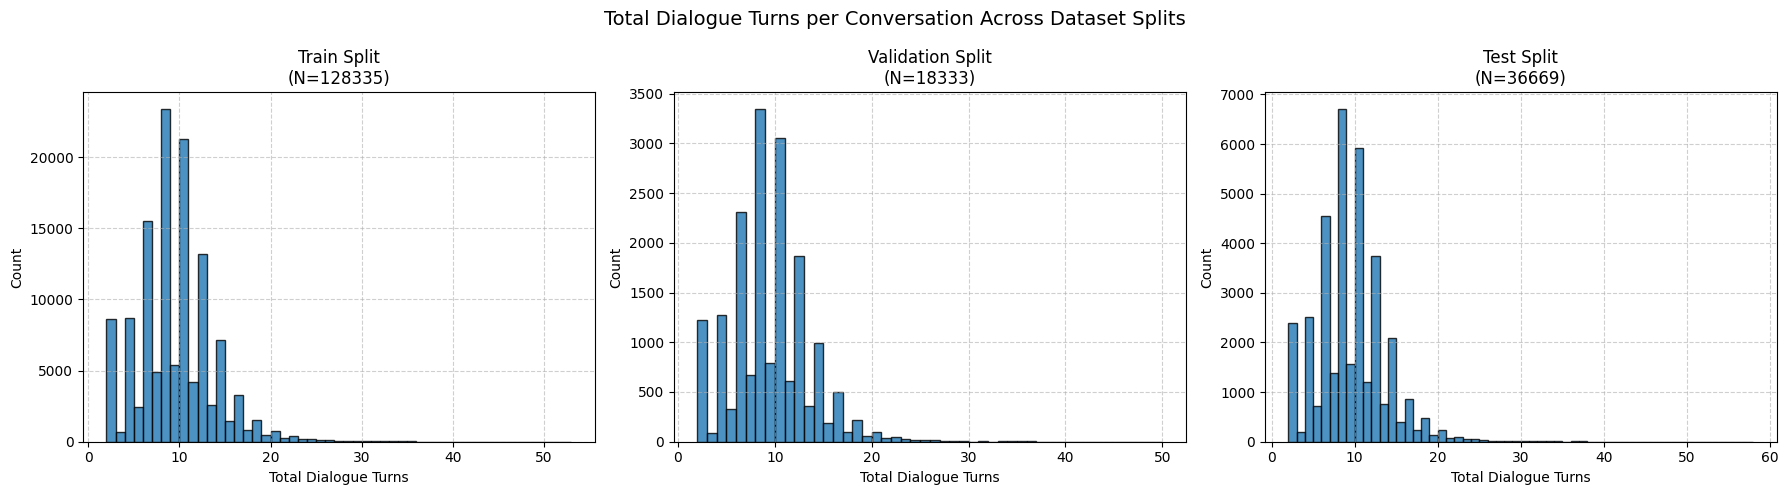

In [ ]:
import re
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

# Match role-labelled turns in conversation history
PAT = re.compile(r'^\s*(agent|client)\s*:', re.IGNORECASE | re.MULTILINE)

def count_history_turns(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return len(PAT.findall(text))

def has_text(x):
    return isinstance(x, str) and x.strip() != ""

# Load dataset
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

# Store turn counts per split
splits_data = {}

for split in ("train", "validation", "test"):
    if split not in dataset:
        continue

    df = dataset[split].to_pandas()

    # Count history turns
    history_turns = (
        df["conversation_history"].map(count_history_turns)
        if "conversation_history" in df.columns
        else 0
    )

    # Add current client + agent turns
    client_add = (
        df["client_question"].map(lambda x: 1 if has_text(x) else 0)
        if "client_question" in df.columns
        else 0
    )

    agent_add = (
        df["generated_answer"].map(lambda x: 1 if has_text(x) else 0)
        if "generated_answer" in df.columns
        else 0
    )

    # Total turns per example
    df["num_turns"] = history_turns + client_add + agent_add

    splits_data[split] = df["num_turns"]

# Plot all splits side by side
fig, axes = plt.subplots(1, len(splits_data), figsize=(18, 5), sharey=False)

for ax, (split, turns) in zip(axes, splits_data.items()):
    n = len(turns)
    max_turns = int(turns.max()) if n else 2

    # Minimum possible turns is 2 (client + agent)
    bins = range(2, max_turns + 2)

    ax.hist(
        turns,
        bins=bins,
        edgecolor="black",
        alpha=0.8
    )
    ax.set_title(f"{split.capitalize()} Split\n(N={n})")
    ax.set_xlabel("Total Dialogue Turns")
    ax.set_ylabel("Count")
    ax.grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Total Dialogue Turns per Conversation Across Dataset Splits", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import re
from datasets import load_dataset
import pandas as pd

# Count "Agent:" / "Client:" lines at start of line (case-insensitive)
PAT = re.compile(r'^\s*(agent|client)\s*:', re.IGNORECASE | re.MULTILINE)

def count_history_turns(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return len(PAT.findall(text))

def has_text(x):
    return isinstance(x, str) and x.strip() != ""

# Load dataset
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

# Detect which column contains the agent reply (adjust if your dataset uses a different name)
AGENT_COL_CANDIDATES = [
    "generated_answer", "ground_truth", "agent_answer", "agent_response",
    "assistant_response", "response"
]

for split in ("train", "validation", "test"):
    if split not in dataset:
        continue

    df = dataset[split].to_pandas()

    # pick the first agent column that exists
    agent_col = next((c for c in AGENT_COL_CANDIDATES if c in df.columns), None)

    # history role-lines count
    hist_turns = df["conversation_history"].map(count_history_turns) if "conversation_history" in df.columns else 0

    # +1 for current client question (if present)
    client_add = df["client_question"].map(lambda x: 1 if has_text(x) else 0) if "client_question" in df.columns else 0

    # +1 for current agent answer (if present)
    agent_add = df[agent_col].map(lambda x: 1 if has_text(x) else 0) if agent_col else 0

    df["num_turns_total"] = hist_turns + client_add + agent_add

    # Print statistics for each split
    print(f"\n{split.upper()} SPLIT STATISTICS")
    print(f"Total Examples      : {len(df)}")
    print(f"Total Turns (sum)   : {int(df['num_turns_total'].sum())}")
    print(f"Minimum Turns       : {int(df['num_turns_total'].min())}")
    print(f"Average Turns       : {df['num_turns_total'].mean():.2f}")
    print(f"Maximum Turns       : {int(df['num_turns_total'].max())}")


TRAIN SPLIT STATISTICS
Total Examples      : 128335
Total Turns (sum)   : 1291138
Minimum Turns       : 2
Average Turns       : 10.06
Maximum Turns       : 53

VALIDATION SPLIT STATISTICS
Total Examples      : 18333
Total Turns (sum)   : 183364
Minimum Turns       : 2
Average Turns       : 10.00
Maximum Turns       : 50

TEST SPLIT STATISTICS
Total Examples      : 36669
Total Turns (sum)   : 368650
Minimum Turns       : 2
Average Turns       : 10.05
Maximum Turns       : 58


In [ ]:
import re
import pandas as pd
from datasets import load_dataset

PAT = re.compile(r'^\s*(agent|client)\s*:', re.IGNORECASE | re.MULTILINE)

def count_history_turns(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return len(PAT.findall(text))

def has_text(x):
    return isinstance(x, str) and x.strip() != ""

repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

AGENT_COL_CANDIDATES = [
    "generated_answer", "ground_truth",
    "agent_answer", "agent_response",
    "assistant_response", "response"
]

stats_rows = []

for split in ("train", "validation", "test"):
    if split not in dataset:
        continue

    df = dataset[split].to_pandas()

    # Detect agent column
    agent_col = next((c for c in AGENT_COL_CANDIDATES if c in df.columns), None)

    # Compute turns
    hist_turns = (
        df["conversation_history"].map(count_history_turns)
        if "conversation_history" in df.columns else 0
    )

    client_add = (
        df["client_question"].map(lambda x: 1 if has_text(x) else 0)
        if "client_question" in df.columns else 0
    )

    agent_add = (
        df[agent_col].map(lambda x: 1 if has_text(x) else 0)
        if agent_col else 0
    )

    df["num_turns_total"] = hist_turns + client_add + agent_add

    # Collect stats
    stats_rows.append({
        "Split": split,
        "Total Samples": len(df),
        "Total Turns": int(df["num_turns_total"].sum()),
        "Min Turns": int(df["num_turns_total"].min()),
        "Avg Turns": round(df["num_turns_total"].mean(), 2),
        "Max Turns": int(df["num_turns_total"].max()),
    })

# Build table
stats_df = pd.DataFrame(stats_rows)

display(stats_df)

,Split,Total Samples,Total Turns,Min Turns,Avg Turns,Max Turns
0,train,128335,1291138,2,10.06,53
1,validation,18333,183364,2,10.00,50
2,test,36669,368650,2,10.05,58


#### White Space Word Count Distribution

In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset

def count_words(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return len(text.split())

# Load dataset
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

# Columns to analyse
cols = ["instruction", "history_summary", "client_question", "refined_agent_answer"]

stats_rows = []

for split in ("train", "validation", "test"):
    if split not in dataset:
        continue

    df = dataset[split].to_pandas()

    for col in cols:
        if col not in df.columns:
            continue

        word_counts = df[col].map(count_words)

        stats_rows.append({
            "Split": split,
            "Column": col,
            "Examples": len(word_counts),
            "Min Words": int(word_counts.min()),
            "Avg Words": round(word_counts.mean(), 2),
            "Median Words": int(np.median(word_counts)),
            "Max Words": int(word_counts.max()),
            "Q1 (25%)": int(np.percentile(word_counts, 25)),
            "Q3 (75%)": int(np.percentile(word_counts, 75)),
        })

In [ ]:
stats_df = pd.DataFrame(stats_rows)
display(stats_df)

,Split,Column,Examples,Min Words,Avg Words,Median Words,Max Words,Q1 (25%),Q3 (75%)
0,train,instruction,128335,93,93.83,94,95,93,95
1,train,history_summary,128335,0,90.12,91,210,72,109
2,train,client_question,128335,1,15.05,13,103,8,20
3,train,refined_agent_answer,128335,5,35.39,34,106,27,43
4,validation,instruction,18333,93,93.84,94,95,93,95
5,validation,history_summary,18333,0,89.93,91,201,72,109
6,validation,client_question,18333,2,14.98,13,115,8,19
7,validation,refined_agent_answer,18333,7,35.35,35,96,26,43
8,test,instruction,36669,93,93.84,94,95,93,95
9,test,history_summary,36669,0,90.08,91,205,72,109


In [ ]:
import pandas as pd
from datasets import load_dataset

def count_words(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return len(text.split())

def count_words_all_fields(row, fields):
    total = 0
    for f in fields:
        if f in row and isinstance(row[f], str):
            total += count_words(row[f])
    return total

# Load dataset
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

# Fields to count words from
text_fields = ["instruction", "client_question", "refined_agent_answer", "history_summary"]

rows = []

for split in ("train", "test", "validation"):
    if split not in dataset:
        continue

    df = dataset[split].to_pandas()

    # Count total words per sample (across all fields)
    df["total_words"] = df.apply(
        lambda r: count_words_all_fields(r, text_fields),
        axis=1
    )

    rows.append({
        "split": split,
        "num_samples": len(df),
        "total_words": int(df["total_words"].sum()),
        "avg_words_per_sample": round(df["total_words"].mean(), 6),
        "max_words_in_sample": int(df["total_words"].max()),
        "min_words_in_sample": int(df["total_words"].min()),
    })

In [ ]:
# Final DataFrame
word_stats_df = pd.DataFrame(rows)

display(word_stats_df)

,split,num_samples,total_words,avg_words_per_sample,max_words_in_sample,min_words_in_sample
0,train,128335,30080815,234.392917,387,118
1,test,36669,8600414,234.541820,414,124
2,validation,18333,4291635,234.093438,378,125


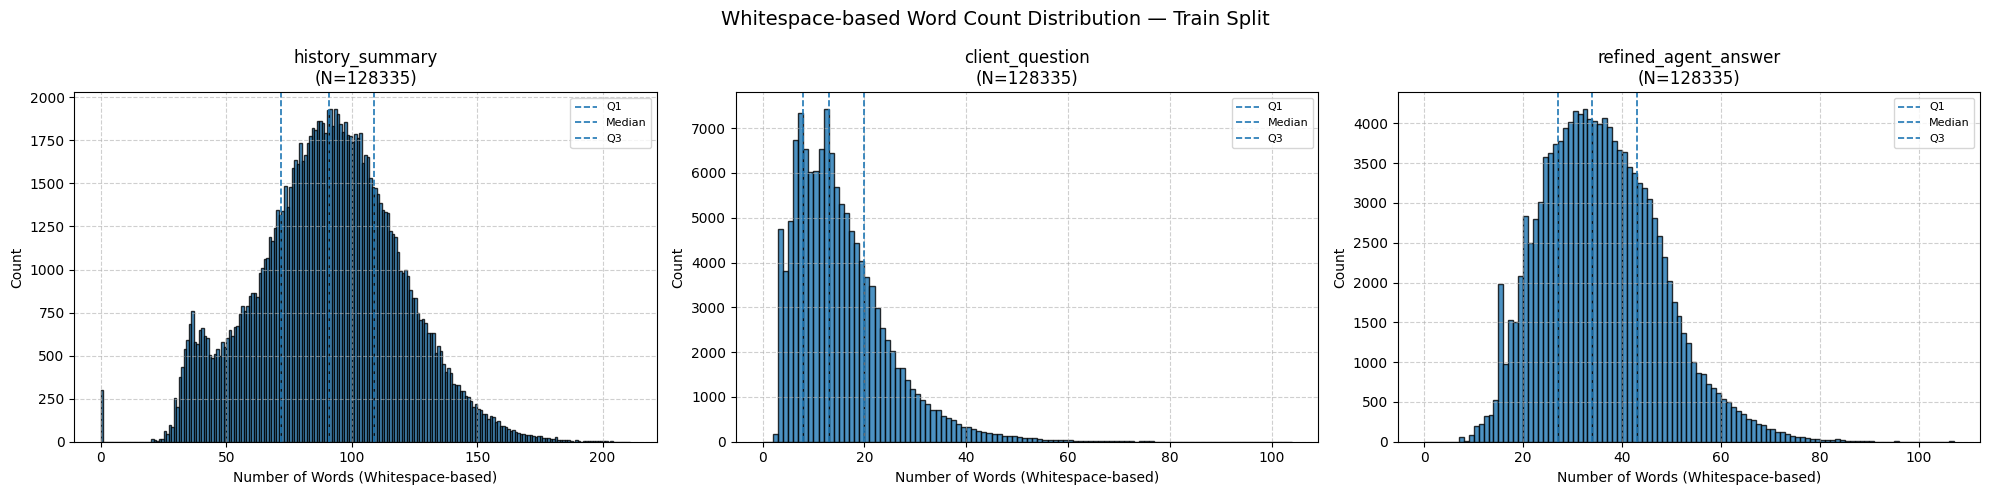

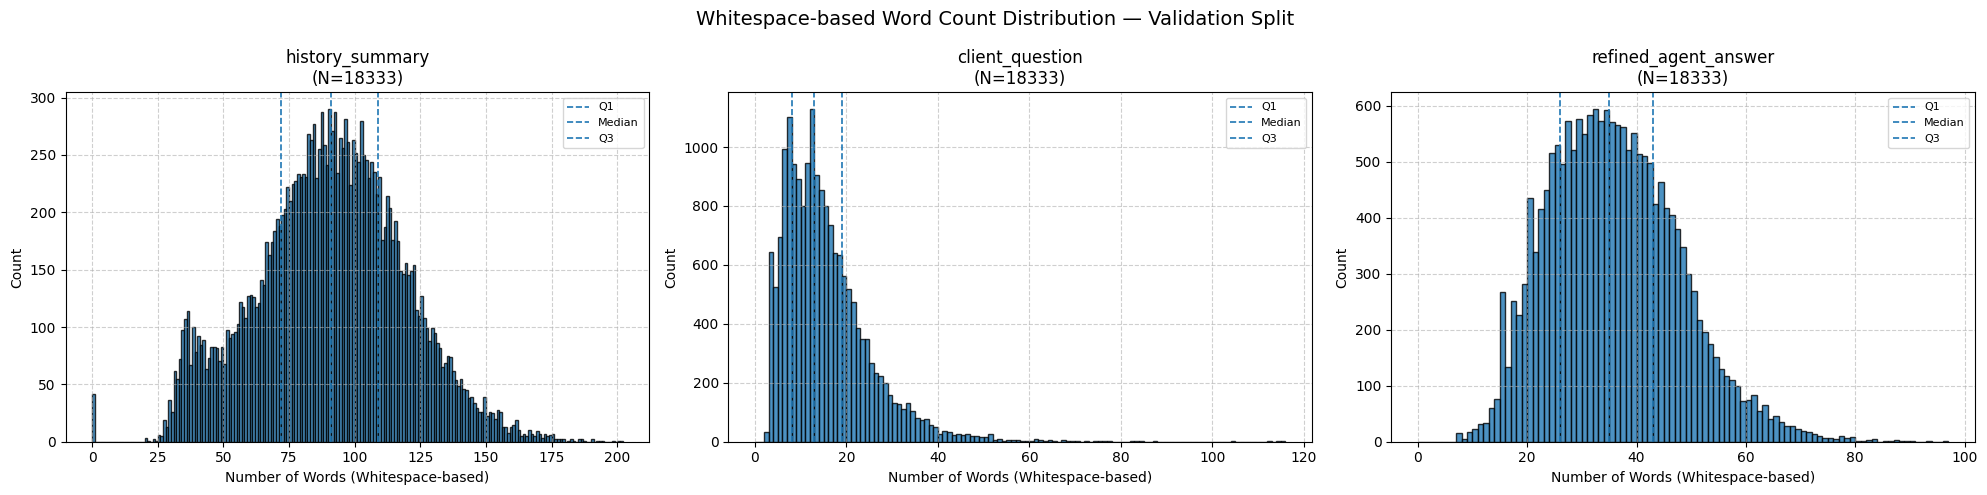

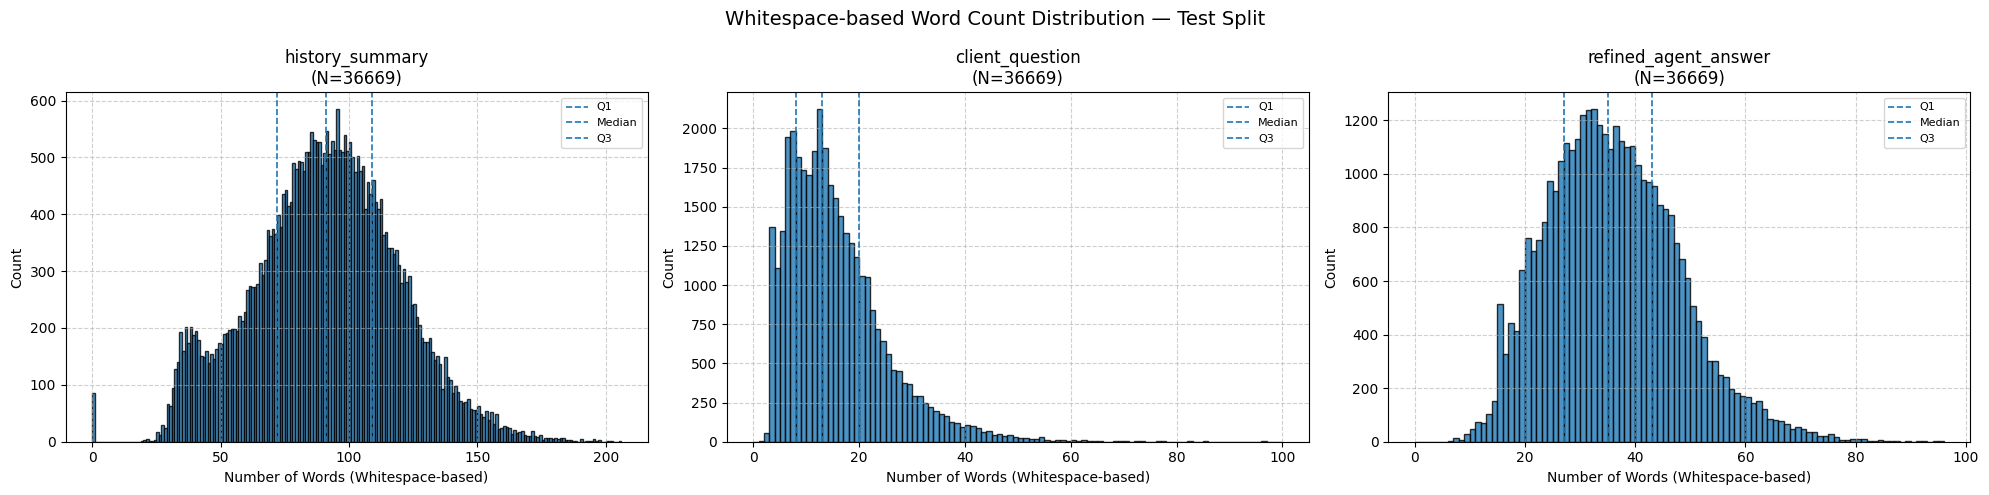

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

def count_words(text):
    if not isinstance(text, str) or not text.strip():
        return 0
    return len(text.split())

# Load dataset
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

# Columns to analyse (instruction REMOVED)
cols = ["history_summary", "client_question", "refined_agent_answer"]

# Plot per split, per column
for split in ("train", "validation", "test"):
    if split not in dataset:
        continue

    df = dataset[split].to_pandas()

    fig, axes = plt.subplots(1, len(cols), figsize=(20, 5), sharey=False)

    for ax, col in zip(axes, cols):
        if col not in df.columns:
            ax.axis("off")
            continue

        word_counts = df[col].map(count_words)
        n = len(word_counts)

        max_words = int(word_counts.max()) if n else 1
        bins = range(0, max_words + 2)

        ax.hist(
            word_counts,
            bins=bins,
            edgecolor="black",
            alpha=0.8
        )

        # Quartiles
        q25, q50, q75 = np.percentile(word_counts, [25, 50, 75])
        ax.axvline(q25, linestyle="--", linewidth=1.2, label="Q1")
        ax.axvline(q50, linestyle="--", linewidth=1.2, label="Median")
        ax.axvline(q75, linestyle="--", linewidth=1.2, label="Q3")

        ax.set_title(f"{col}\n(N={n})")
        ax.set_xlabel("Number of Words (Whitespace-based)")
        ax.set_ylabel("Count")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Whitespace-based Word Count Distribution — {split.capitalize()} Split",
        fontsize=14
    )
    plt.tight_layout()
    plt.show()

### Total token count distribution

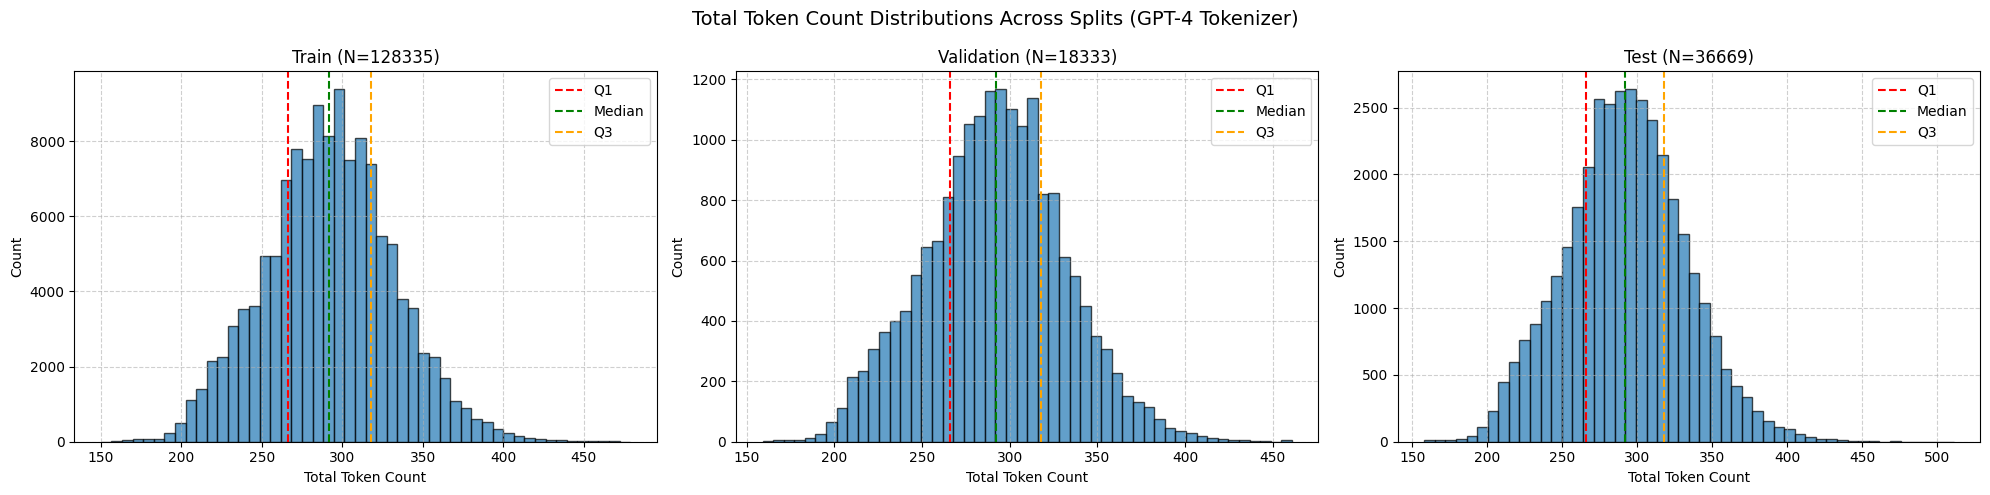

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import tiktoken

# GPT-4 tokenizer
enc = tiktoken.encoding_for_model("gpt-4")
count_tokens = lambda x: len(enc.encode(x)) if x else 0

# Dataset + columns
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
cols = ["instruction", "history_summary", "client_question", "refined_agent_answer"]
dataset = load_dataset(repo_id)

# Compute total tokens per record (sum across all 4 columns)
splits_data = {
    s: dataset[s].to_pandas()[cols].apply(
        lambda r: sum(count_tokens(str(r[c])) for c in cols), axis=1
    )
    for s in ("train", "validation", "test") if s in dataset
}

# Plot 3 splits side by side in one row
fig, axes = plt.subplots(1, len(splits_data), figsize=(20, 5), sharey=False)

for ax, (split, tokens) in zip(axes, splits_data.items()):
    ax.hist(tokens, bins=50, color="#1f77b4", edgecolor="black", alpha=0.7)

    # Quartiles
    q25, q50, q75 = np.percentile(tokens, [25, 50, 75])
    for q, color, label in zip([q25, q50, q75],
                               ["red", "green", "orange"],
                               ["Q1", "Median", "Q3"]):
        ax.axvline(q, color=color, ls="--", lw=1.5, label=label)

    ax.set_title(f"{split.capitalize()} (N={len(tokens)})")
    ax.set_xlabel("Total Token Count")
    ax.set_ylabel("Count")
    ax.grid(True, ls="--", alpha=0.6)
    ax.legend()

plt.suptitle("Total Token Count Distributions Across Splits (GPT-4 Tokenizer)", fontsize=14)
plt.tight_layout()
plt.show()

### Token Distribution for Agent Answer with GPT-4 Tokenizer

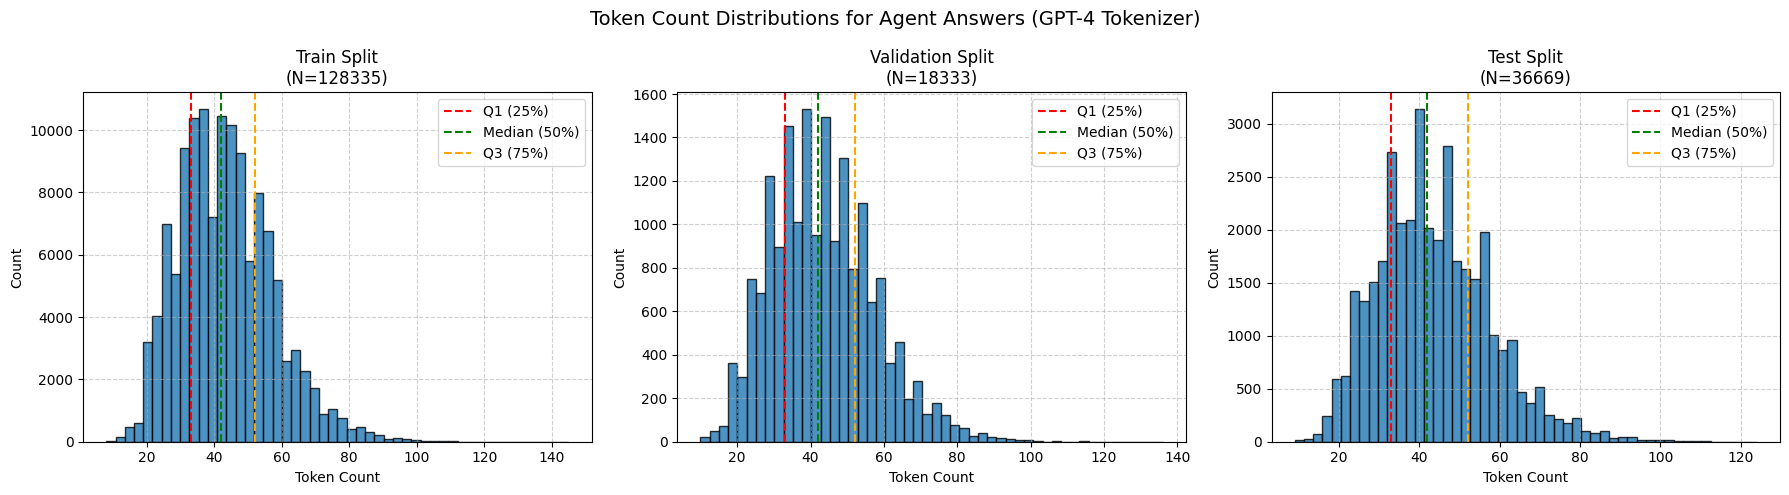

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import tiktoken  # OpenAI tokenizer

# Load GPT-4 tokenizer
enc = tiktoken.encoding_for_model("gpt-4")

def count_tokens(text):
    if not text:
        return 0
    return len(enc.encode(text))

# Load dataset
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

# Collect token counts for all splits
splits_data = {}
for split in ("train", "validation", "test"):
    if split not in dataset:
        continue

    df = dataset[split].to_pandas()
    # change column here
    df["num_tokens"] = df["refined_agent_answer"].map(count_tokens)
    splits_data[split] = df["num_tokens"]

# Plot all splits side by side with quartiles
fig, axes = plt.subplots(1, len(splits_data), figsize=(18, 5), sharey=False)

for ax, (split, tokens) in zip(axes, splits_data.items()):
    n = len(tokens)
    bins = 50  # fixed number of bins for smoother view

    # Histogram
    ax.hist(
        tokens,
        bins=bins,
        edgecolor="black",
        color="#1f77b4",  # dark blue
        alpha=0.8
    )

    # Quartiles
    q25, q50, q75 = np.percentile(tokens, [25, 50, 75])
    for q, color, label in zip([q25, q50, q75],
                               ["red", "green", "orange"],
                               ["Q1 (25%)", "Median (50%)", "Q3 (75%)"]):
        ax.axvline(q, color=color, linestyle="--", linewidth=1.5, label=label)

    # Labels
    ax.set_title(f"{split.capitalize()} Split\n(N={n})")
    ax.set_xlabel("Token Count")
    ax.set_ylabel("Count")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

plt.suptitle("Token Count Distributions for Agent Answers (GPT-4 Tokenizer)", fontsize=14)
plt.tight_layout()
plt.show()

## Percentile wise token count analysis for agent answer

In [ ]:
import numpy as np
from datasets import load_dataset
import tiktoken

# GPT-4 tokenizer
enc = tiktoken.encoding_for_model("gpt-4")
count_tokens = lambda x: len(enc.encode(x)) if x else 0

# Load dataset
repo_id = "Lakshan2003/customer-support-client-agent-conversations"
dataset = load_dataset(repo_id)

# Check refined_agent_answer only
for split in ("train", "validation", "test"):
    if split not in dataset:
        continue
    df = dataset[split].to_pandas()
    tokens = df["refined_agent_answer"].map(count_tokens)

    p95 = np.percentile(tokens, 95)
    p99 = np.percentile(tokens, 99)
    max_t = tokens.max()

    print(f"{split.capitalize()} Split:")
    print(f"  95th percentile: {p95:.0f}")
    print(f"  99th percentile: {p99:.0f}")
    print(f"  Max: {max_t}")
    print(f"  % <=100: {(tokens <= 100).mean()*100:.2f}%\n")

README.md:   0%|          | 0.00/809 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/148M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/21.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/128335 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/36669 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/18333 [00:00<?, ? examples/s]

Train Split:
  95th percentile: 68
  99th percentile: 83
  Max: 145
  % <=100: 99.90%

Validation Split:
  95th percentile: 68
  99th percentile: 82
  Max: 136
  % <=100: 99.92%

Test Split:
  95th percentile: 69
  99th percentile: 83
  Max: 124
  % <=100: 99.90%

